In [1]:
from ontocast.tool.triple_manager.fuseki import FusekiTripleStoreManager
import pandas as pd
import matplotlib.pyplot as plt
import seaborn
import polars
from pathlib import Path
import numpy as np
import polars as pl

In [2]:
# Load environment variables from project files (keys first, then ontology config).
import os
from dotenv import load_dotenv

cwd = Path.cwd().resolve()
repo_root = cwd.parent if (cwd / "ontology.env").exists() else cwd
keys_env = repo_root / "keys.env"
ontology_env = repo_root / "ontology" / "ontology.env"

if not keys_env.exists():
    raise FileNotFoundError(f"Missing env file: {keys_env}")
if not ontology_env.exists():
    raise FileNotFoundError(f"Missing env file: {ontology_env}")

load_dotenv(keys_env, override=True)
load_dotenv(ontology_env, override=True)

# Pydantic-settings tries to JSON-decode list fields from env vars before validators run.
# Normalize blank domain allow/block lists so Config() can be created safely.
for env_name in ("WEB_SEARCH_ALLOWED_DOMAINS", "WEB_SEARCH_BLOCKED_DOMAINS"):
    if (os.getenv(env_name) or "").strip() == "":
        os.environ[env_name] = "[]"

# Normalize optional integer field so blank/commented values fall back to OntoCast defaults.
ontology_max_triples_raw = (os.getenv("ONTOLOGY_MAX_TRIPLES") or "").strip()
if not ontology_max_triples_raw or ontology_max_triples_raw.startswith("#"):
    os.environ.pop("ONTOLOGY_MAX_TRIPLES", None)

print(f"Loaded: {keys_env.name}, {ontology_env.name}")
print("OPENAI_API_KEY present:", bool(os.getenv("OPENAI_API_KEY")))
print("LLM_API_KEY present:", bool(os.getenv("LLM_API_KEY")))
print("WEB_SEARCH_ALLOWED_DOMAINS:", os.getenv("WEB_SEARCH_ALLOWED_DOMAINS"))
print("WEB_SEARCH_BLOCKED_DOMAINS:", os.getenv("WEB_SEARCH_BLOCKED_DOMAINS"))
print("ONTOLOGY_MAX_TRIPLES:", os.getenv("ONTOLOGY_MAX_TRIPLES", "<default>"))

Loaded: keys.env, ontology.env
OPENAI_API_KEY present: True
LLM_API_KEY present: True
WEB_SEARCH_ALLOWED_DOMAINS: []
WEB_SEARCH_BLOCKED_DOMAINS: []
ONTOLOGY_MAX_TRIPLES: <default>


In [3]:
# Config
import os

FUSEKI_BASE_URI = os.getenv("FUSEKI_URI", "http://localhost:3032")
DATASET_NAME = os.getenv("FUSEKI_DATASET", "ds")

fuseki_auth_raw = os.getenv("FUSEKI_AUTH", "admin:test345")
AUTH = tuple(fuseki_auth_raw.split(":", 1)) if ":" in fuseki_auth_raw else ("admin", "test345")

In [4]:
# Test connection in a worker thread so asyncio.run() is not called inside Jupyter's running loop.
from concurrent.futures import ThreadPoolExecutor

print(f"Connecting to {FUSEKI_BASE_URI}...")

def _init_manager():
    return FusekiTripleStoreManager(
        uri=FUSEKI_BASE_URI,
        dataset=DATASET_NAME,
        auth=AUTH,
    )

try:
    with ThreadPoolExecutor(max_workers=1) as pool:
        manager = pool.submit(_init_manager).result()

    print(f"SUCCESS: Manager initialized for dataset '{DATASET_NAME}'")
    print("Local endpoint is reachable from this notebook kernel.")
except Exception as e:
    print(f"Initialization failed: {e}")

Connecting to http://localhost:3032...
Initialization failed: All connection attempts failed


### Data Subset for Initial Testing

In [5]:
# Check Article 6 limb coverage in initial (raw) metadata before text filtering
if "judgments_metadata_raw" not in globals() or "decisions_metadata_raw" not in globals():
    DATA_DIR = Path("../data")
    judgments_metadata_raw = pl.read_ndjson(
        DATA_DIR / "art_6_judgments_metadata_processed.json",
        infer_schema_length=None,
    ).with_columns(
        pl.lit("judgments").alias("source"),
        pl.col("itemid").cast(pl.Utf8),
    )

    decisions_metadata_raw = pl.read_ndjson(
        DATA_DIR / "art_6_decisions_metadata_processed.json",
        infer_schema_length=None,
    ).with_columns(
        pl.lit("decisions").alias("source"),
        pl.col("itemid").cast(pl.Utf8),
    )

initial_metadata = pl.concat([judgments_metadata_raw, decisions_metadata_raw], how="diagonal_relaxed")

# Compatibility-safe coercion to text for downstream quality checks and tokenization.
article_6_limb_text_expr = pl.col("article_6_limb").cast(pl.Utf8, strict=False).alias("article_6_limb_text")

valid_article_6_limb_expr = (
    pl.col("article_6_limb_text").is_not_null()
    & pl.col("article_6_limb_text").str.strip_chars().is_in(["", "null", "none", "nan", "[]"]).not_()
    & pl.col("article_6_limb_text").str.strip_chars().str.to_lowercase().is_in(["n/a", "na"]).not_()
)

initial_with_limb = initial_metadata.with_columns(article_6_limb_text_expr)

article_6_limb_by_source = (
    initial_with_limb
    .group_by("source")
    .agg(
        pl.len().alias("total_cases"),
        valid_article_6_limb_expr.sum().alias("article_6_limb_captured"),
    )
    .with_columns(
        (pl.col("article_6_limb_captured") / pl.col("total_cases") * 100).round(2).alias("captured_pct")
    )
    .sort("source")
)

article_6_limb_overall = initial_with_limb.select(
    pl.len().alias("total_cases"),
    valid_article_6_limb_expr.sum().alias("article_6_limb_captured"),
).with_columns(
    (pl.col("article_6_limb_captured") / pl.col("total_cases") * 100).round(2).alias("captured_pct")
)

# Breakdown by individual limb label
limb_labels = (
    initial_with_limb
    .filter(valid_article_6_limb_expr)
    .with_columns(
        pl.col("article_6_limb_text")
        .str.to_lowercase()
        .str.replace_all(r"[\\[\\]\"]", "")
        .str.replace_all(r"\\s+", " ")
        .str.replace_all(r"\\s*[,/|]\\s*", ";")
        .str.split(";")
        .alias("limb_tokens")
    )
    .explode("limb_tokens")
    .with_columns(pl.col("limb_tokens").str.strip_chars().alias("limb_label"))
    .filter(
        pl.col("limb_label").is_not_null()
        & pl.col("limb_label").is_in(["", "null", "none", "nan", "n/a", "na"]).not_()
    )
)

article_6_limb_label_breakdown = (
    limb_labels
    .group_by("limb_label")
    .agg(pl.len().alias("case_count"))
    .sort("case_count", descending=True)
)

article_6_limb_label_by_source = (
    limb_labels
    .group_by(["source", "limb_label"])
    .agg(pl.len().alias("case_count"))
    .sort(["source", "case_count"], descending=[False, True])
)

article_6_limb_unique_values = (
    initial_with_limb
    .select(pl.col("article_6_limb_text").str.strip_chars().alias("article_6_limb_text"))
    .group_by("article_6_limb_text")
    .agg(pl.len().alias("case_count"))
    .sort("case_count", descending=True)
)

article_6_limb_by_source, article_6_limb_overall, article_6_limb_label_breakdown, article_6_limb_label_by_source, article_6_limb_unique_values

(shape: (2, 4)
 ┌───────────┬─────────────┬─────────────────────────┬──────────────┐
 │ source    ┆ total_cases ┆ article_6_limb_captured ┆ captured_pct │
 │ ---       ┆ ---         ┆ ---                     ┆ ---          │
 │ str       ┆ u32         ┆ u32                     ┆ f64          │
 ╞═══════════╪═════════════╪═════════════════════════╪══════════════╡
 │ decisions ┆ 33603       ┆ 33603                   ┆ 100.0        │
 │ judgments ┆ 15316       ┆ 15316                   ┆ 100.0        │
 └───────────┴─────────────┴─────────────────────────┴──────────────┘,
 shape: (1, 3)
 ┌─────────────┬─────────────────────────┬──────────────┐
 │ total_cases ┆ article_6_limb_captured ┆ captured_pct │
 │ ---         ┆ ---                     ┆ ---          │
 │ u32         ┆ u32                     ┆ f64          │
 ╞═════════════╪═════════════════════════╪══════════════╡
 │ 48919       ┆ 48919                   ┆ 100.0        │
 └─────────────┴─────────────────────────┴──────────────┘,
 s

In [6]:
SEED = 42
TARGET_PER_LEVEL = 50
DATA_DIR = Path("../data")
TEXT_DIR = DATA_DIR / "processed_json"

import re

itemid_pattern = re.compile(r'"itemid"\s*:\s*"([^"]+)"')

def load_text_itemids(jsonl_path: Path) -> set[str]:
    itemids = set()
    with jsonl_path.open("r", encoding="utf-8", errors="replace") as f:
        for line in f:
            match = itemid_pattern.search(line)
            if match:
                itemids.add(match.group(1))
    return itemids

judgment_text_itemids = sorted(load_text_itemids(TEXT_DIR / "echr_corpus.jsonl"))
decision_text_itemids = sorted(load_text_itemids(TEXT_DIR / "echr_decisions_corpus.jsonl"))

judgments_metadata_raw = pl.read_ndjson(
    DATA_DIR / "art_6_judgments_metadata_processed.json",
    infer_schema_length=None,
).with_columns(
    pl.lit("judgments").alias("source"),
    pl.col("itemid").cast(pl.Utf8),
)

decisions_metadata_raw = pl.read_ndjson(
    DATA_DIR / "art_6_decisions_metadata_processed.json",
    infer_schema_length=None,
).with_columns(
    pl.lit("decisions").alias("source"),
    pl.col("itemid").cast(pl.Utf8),
)

judgments_metadata = judgments_metadata_raw.filter(pl.col("itemid").is_in(judgment_text_itemids))
decisions_metadata = decisions_metadata_raw.filter(pl.col("itemid").is_in(decision_text_itemids))

metadata_text_filter_summary = pl.DataFrame(
    {
        "source": ["judgments", "decisions"],
        "metadata_rows_before": [judgments_metadata_raw.height, decisions_metadata_raw.height],
        "metadata_rows_after": [judgments_metadata.height, decisions_metadata.height],
    }
).with_columns(
    (pl.col("metadata_rows_before") - pl.col("metadata_rows_after")).alias("rows_without_text")
)

metadata = pl.concat([judgments_metadata, decisions_metadata], how="diagonal_relaxed")

metadata = metadata.with_columns(
    pl.coalesce(
        [
            pl.col("judgementdate").cast(pl.Utf8).str.slice(0, 4).cast(pl.Int32, strict=False),
            pl.col("ecli").cast(pl.Utf8).str.extract(r":(\d{4}):", 1).cast(pl.Int32, strict=False),
        ]
    ).alias("year")
)

metadata_for_sampling = metadata.filter(pl.col("court_level").is_not_null() & pl.col("year").is_not_null())

def temporal_spread_sample(group_df: pl.DataFrame, target_n: int) -> pl.DataFrame:
    """Sample across the whole time span by taking evenly spaced points on sorted year."""

    n = group_df.height
    if n <= target_n:
        return group_df

    sorted_df = group_df.sort("year")
    idx = np.linspace(0, n - 1, num=target_n, dtype=int)

    return (
        sorted_df.with_row_index("_row_idx")
        .filter(pl.col("_row_idx").is_in(idx.tolist()))
        .drop("_row_idx")
    )

sampled_groups = []
for level in sorted(metadata_for_sampling["court_level"].unique().to_list()):
    level_df = metadata_for_sampling.filter(pl.col("court_level") == level)
    sampled_groups.append(temporal_spread_sample(level_df, TARGET_PER_LEVEL))

sampled_metadata = pl.concat(sampled_groups, how="diagonal_relaxed")

full_summary = (
    metadata_for_sampling.group_by("court_level")
    .agg(
        pl.len().alias("full_n"),
        pl.col("year").min().alias("full_year_min"),
        pl.col("year").max().alias("full_year_max"),
    )
)

sample_summary = (
    sampled_metadata.group_by("court_level")
    .agg(
        pl.len().alias("sample_n"),
        pl.col("year").min().alias("sample_year_min"),
        pl.col("year").max().alias("sample_year_max"),
    )
)

sampling_summary = full_summary.join(sample_summary, on="court_level", how="left").sort("court_level")

metadata_text_filter_summary, sampling_summary

(shape: (2, 4)
 ┌───────────┬──────────────────────┬─────────────────────┬───────────────────┐
 │ source    ┆ metadata_rows_before ┆ metadata_rows_after ┆ rows_without_text │
 │ ---       ┆ ---                  ┆ ---                 ┆ ---               │
 │ str       ┆ i64                  ┆ i64                 ┆ i64               │
 ╞═══════════╪══════════════════════╪═════════════════════╪═══════════════════╡
 │ judgments ┆ 15316                ┆ 15305               ┆ 11                │
 │ decisions ┆ 33603                ┆ 33019               ┆ 584               │
 └───────────┴──────────────────────┴─────────────────────┴───────────────────┘,
 shape: (7, 7)
 ┌───────────────┬────────┬───────────────┬───────────────┬──────────┬───────────────┬──────────────┐
 │ court_level   ┆ full_n ┆ full_year_min ┆ full_year_max ┆ sample_n ┆ sample_year_m ┆ sample_year_ │
 │ ---           ┆ ---    ┆ ---           ┆ ---           ┆ ---      ┆ in            ┆ max          │
 │ str           ┆ u32 

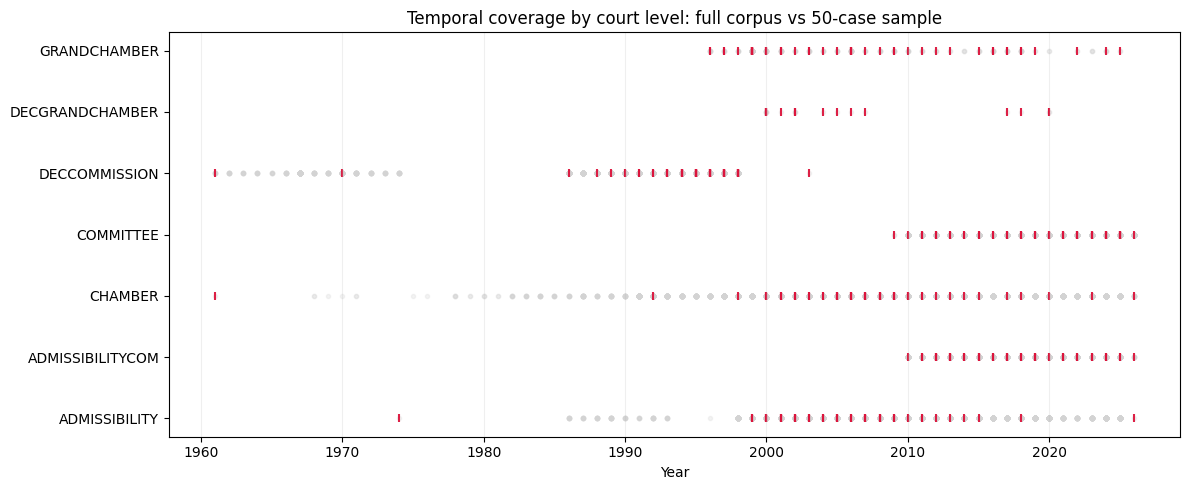

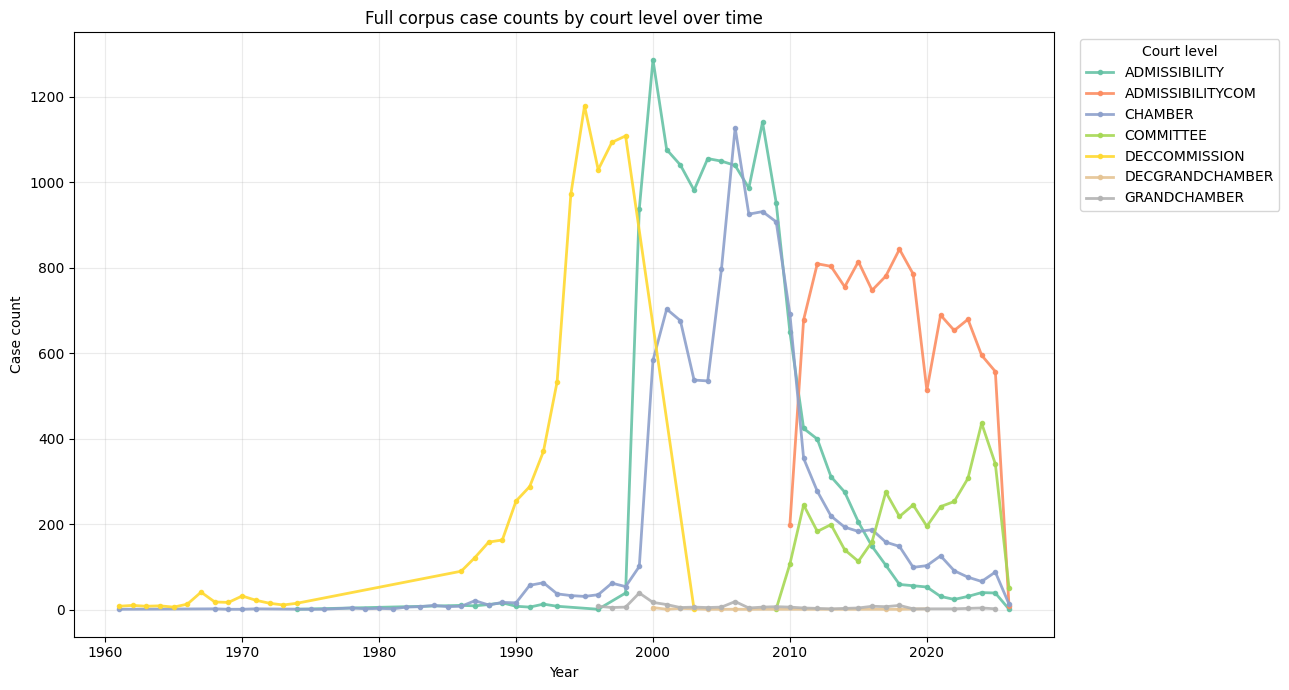

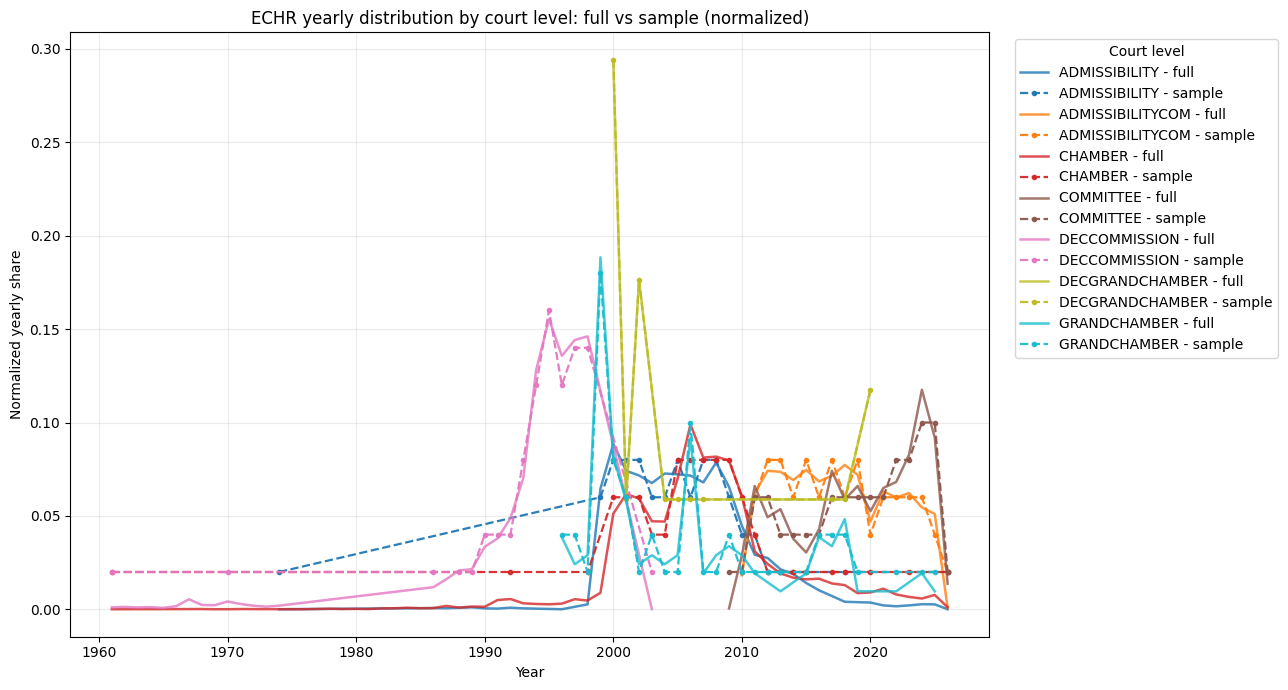

In [7]:
levels = sampling_summary["court_level"].to_list()

# Time coverage: full corpus (gray) vs sampled cases (red) per level
fig, ax = plt.subplots(figsize=(12, max(5, len(levels) * 0.7)))
for i, level in enumerate(levels):
    full_years = metadata_for_sampling.filter(pl.col("court_level") == level)["year"].to_list()
    sample_years = sampled_metadata.filter(pl.col("court_level") == level)["year"].to_list()

    ax.scatter(full_years, [i] * len(full_years), s=9, color="lightgray", alpha=0.25)
    ax.scatter(sample_years, [i] * len(sample_years), s=35, color="crimson", alpha=0.95, marker="|")

ax.set_yticks(range(len(levels)))
ax.set_yticklabels(levels)
ax.set_xlabel("Year")
ax.set_title("Temporal coverage by court level: full corpus vs 50-case sample")
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

# Full-corpus trend over time by court level (no sample overlay)
full_yearly_counts = (
    metadata_for_sampling
    .group_by(["year", "court_level"])
    .agg(pl.len().alias("full_case_count"))
    .sort(["court_level", "year"])
    .to_pandas()
)

levels_sorted_full = sorted(full_yearly_counts["court_level"].dropna().unique())
colors_full = plt.cm.Set2(np.linspace(0, 1, len(levels_sorted_full)))

plt.figure(figsize=(13, 7))
for color, level in zip(colors_full, levels_sorted_full):
    level_df = full_yearly_counts[full_yearly_counts["court_level"] == level]
    plt.plot(
        level_df["year"],
        level_df["full_case_count"],
        color=color,
        linewidth=2.0,
        marker="o",
        markersize=3,
        alpha=0.9,
        label=str(level),
    )

plt.xlabel("Year")
plt.ylabel("Case count")
plt.title("Full corpus case counts by court level over time")
plt.legend(title="Court level", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Yearly normalized comparison per court level (full metadata vs sampled subset)
yearly_counts = (
    metadata_for_sampling
    .group_by(["year", "court_level"])
    .agg(pl.len().alias("full_case_count"))
    .with_columns(
        (
            pl.col("full_case_count")
            / pl.col("full_case_count").sum().over("court_level")
        ).alias("full_case_share")
    )
    .sort(["court_level", "year"])
)

yearly_counts_sample = (
    sampled_metadata
    .group_by(["year", "court_level"])
    .agg(pl.len().alias("sample_case_count"))
    .with_columns(
        (
            pl.col("sample_case_count")
            / pl.col("sample_case_count").sum().over("court_level")
        ).alias("sample_case_share")
    )
    .sort(["court_level", "year"])
)

levels_sorted = yearly_counts["court_level"].unique().sort().to_list()
colors = plt.cm.tab10(np.linspace(0, 1, len(levels_sorted)))

plt.figure(figsize=(13, 7))
for color, level in zip(colors, levels_sorted):
    level_full = yearly_counts.filter(pl.col("court_level") == level)
    level_sample = yearly_counts_sample.filter(pl.col("court_level") == level)

    plt.plot(
        level_full["year"].to_list(),
        level_full["full_case_share"].to_list(),
        color=color,
        linewidth=1.8,
        alpha=0.8,
        label=f"{level} - full",
    )

    plt.plot(
        level_sample["year"].to_list(),
        level_sample["sample_case_share"].to_list(),
        color=color,
        linestyle="--",
        marker="o",
        markersize=3,
        linewidth=1.6,
        alpha=0.95,
        label=f"{level} - sample",
    )

plt.xlabel("Year")
plt.ylabel("Normalized yearly share")
plt.title("ECHR yearly distribution by court level: full vs sample (normalized)")
plt.legend(title="Court level", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [21]:
# Add full text and JSON-native text section labels to sampled metadata
import json
import re

TEXT_DIR = Path("../data/processed_json")

required_cols = {"itemid", "source"}
missing_cols = required_cols - set(sampled_metadata.columns)
if missing_cols:
    raise ValueError(f"sampled_metadata is missing required columns: {sorted(missing_cols)}")

# Build lookup sets so we only keep text for sampled cases
sample_ids_by_source = {
    "judgments": set(
        sampled_metadata
        .filter(pl.col("source") == "judgments")["itemid"]
        .cast(pl.Utf8)
        .to_list()
    ),
    "decisions": set(
        sampled_metadata
        .filter(pl.col("source") == "decisions")["itemid"]
        .cast(pl.Utf8)
        .to_list()
    ),
}

invalid_escape_re = re.compile(r"\\(?![\"\\/bfnrtu])")

def _safe_json_load(line: str) -> dict | None:
    line = line.strip()
    if not line:
        return None
    try:
        return json.loads(line)
    except json.JSONDecodeError:
        # Repair invalid backslash escapes such as \N in text payloads.
        fixed = invalid_escape_re.sub(r"\\\\", line)
        try:
            return json.loads(fixed)
        except json.JSONDecodeError:
            return None

def _normalize_label(label: str) -> str:
    label = label.strip().lower()
    if label.startswith("the "):
        label = label[4:]
    label = re.sub(r"[^a-z0-9]+", "_", label)
    label = label.strip("_")
    return label

def _extract_json_labeled_sections(raw_text_chunks) -> dict[str, str]:
    labeled: dict[str, list[str]] = {}

    # Preferred shape observed in corpus: {"introduction": "...", "procedure": "...", ...}
    if isinstance(raw_text_chunks, dict):
        for key, value in raw_text_chunks.items():
            label = _normalize_label(str(key))
            if not label:
                continue
            text = value if isinstance(value, str) else json.dumps(value, ensure_ascii=False)
            if text and text.strip():
                labeled.setdefault(label, []).append(text.strip())

    # Secondary supported shape: [{"label": "facts", "text": "..."}, ...]
    elif isinstance(raw_text_chunks, list) and all(isinstance(x, dict) for x in raw_text_chunks):
        for chunk in raw_text_chunks:
            raw_label = chunk.get("label") or chunk.get("section") or chunk.get("title")
            if raw_label is None:
                continue
            label = _normalize_label(str(raw_label))
            if not label:
                continue
            text = chunk.get("text") or chunk.get("content") or ""
            if isinstance(text, str) and text.strip():
                labeled.setdefault(label, []).append(text.strip())

    return {k: "\n\n".join(v) for k, v in labeled.items() if v}

def _derive_sections_for_text_sections(full_text: str | None, raw_text_chunks):
    if isinstance(raw_text_chunks, (dict, list)) and raw_text_chunks:
        return raw_text_chunks
    if isinstance(full_text, str) and full_text.strip():
        # Keep a basic fallback so text_sections is still populated even if chunks are missing.
        sections = [part.strip() for part in full_text.split("\n\n") if part.strip()]
        return sections if sections else None
    return None

def load_text_rows(file_path: Path, source_label: str, keep_ids: set[str]) -> list[dict]:
    rows = []
    with file_path.open("r", encoding="utf-8", errors="replace") as f:
        for line in f:
            obj = _safe_json_load(line)
            if not obj:
                continue

            itemid = obj.get("itemid")
            if itemid is None:
                continue

            itemid_str = str(itemid)
            if itemid_str not in keep_ids:
                continue

            full_text = obj.get("full_text")
            raw_text_chunks = obj.get("text_chunks")
            text_sections = _derive_sections_for_text_sections(full_text, raw_text_chunks)
            labeled_sections = _extract_json_labeled_sections(raw_text_chunks)

            row = {
                "itemid": itemid_str,
                "source": source_label,
                "full_text": full_text,
                "text_sections": text_sections,
            }
            row.update(labeled_sections)
            rows.append(row)
    return rows

text_rows = []
text_rows.extend(
    load_text_rows(
        TEXT_DIR / "echr_corpus.jsonl",
        "judgments",
        sample_ids_by_source["judgments"],
    )
)
text_rows.extend(
    load_text_rows(
        TEXT_DIR / "echr_decisions_corpus.jsonl",
        "decisions",
        sample_ids_by_source["decisions"],
    )
)

text_lookup = (
    pl.from_dicts(text_rows)
    .with_columns(
        pl.col("itemid").cast(pl.Utf8),
        pl.col("source").cast(pl.Utf8),
    )
    .unique(subset=["itemid", "source"], keep="first")
)

# Reset to base metadata schema first so reruns do not accumulate stale section columns.
base_cols = [c for c in sampled_metadata.columns if c in metadata_for_sampling.columns]
sampled_metadata = sampled_metadata.select(base_cols)

sampled_metadata = (
    sampled_metadata
    .with_columns(pl.col("itemid").cast(pl.Utf8))
    .join(text_lookup, on=["itemid", "source"], how="left")
)

# Keep individual section columns only; drop the aggregate text_sections object column.
sampled_metadata = sampled_metadata.drop(["text_sections"], strict=False)

section_label_columns = sorted(
    c for c in text_lookup.columns
    if c not in {"itemid", "source", "full_text", "text_sections"}
    and not c.endswith("_right")
)

match_summary = sampled_metadata.select(
    pl.len().alias("sample_rows"),
    pl.col("full_text").is_not_null().sum().alias("rows_with_full_text"),
    pl.lit(len(section_label_columns)).alias("json_label_section_columns"),
)

match_summary

sample_rows,rows_with_full_text,json_label_section_columns
u32,u32,i32
317,317,7


In [22]:
sampled_metadata


conclusion,violation,languageisocode,originatingbody,itemid,secondary_appno,importance,judgementdate,case_name,ecli,judges,nonviolation,judgment_type,separateopinion,respondent,cited_appno,kpthesaurus,court_level,article,case_appno,case_text_path,appellant,country_name,judges_id,judge_similarity_pct,kpthesaurus_labels,article_6_limb,law_system,source,year,full_text,introduction,procedure,facts,legal_framework,law,reasons,appendix
list[str],list[str],str,str,str,list[str],i64,str,str,str,list[str],list[str],str,str,str,list[str],str,str,list[str],list[str],str,str,list[str],list[i64],list[f64],list[str],str,str,str,i32,str,str,str,str,str,str,str,str
"[""Partiellement recevable"", ""Partiellement irrecevable""]",[],"""FRE""","""Committee of Ministers""","""001-27969""",[],2,null,"""HÄTTI contre ALLEMAGNE""","""ECLI:CE:ECHR:1974:1005DEC00061…",[],[],"""Decision""","""""","""DEU""",[],"""350;193;448;227;445;406;76;14""","""ADMISSIBILITY""","[""3"", ""5"", … ""35-1""]","[""6181/73""]","""./data/decision_text/001-27969…","""HÄTTI contre ALLEMAGNE""","[""Germany""]",[],[],"[""(Art. 3) Prohibition of torture"", ""(Art. 3) Inhuman treatment"", … ""(Art. 35) Admissibility criteria""]","""Criminal""","""Civil""","""decisions""",1974,"""﻿ ## EN FAIT Les faits de la…","""﻿""",null,"""## EN FAIT Les faits de la…",null,"""## EN DROIT **17.** Le requé…","""Par ces motifs, la Commission …",null
"[""Recevable""]",[],"""FRE""","""Court (Second Section)""","""001-30291""",[],4,null,"""F.F. contre l'ITALIE""","""ECLI:CE:ECHR:1999:0427DEC00409…","[""Christos Rozakis""]",[],"""Decision""","""""","""ITA""",[],"""445;40;406""","""ADMISSIBILITY""","[""6"", ""6-1""]","[""40971/98""]","""./data/decision_text/001-30291…","""F.F. contre l'ITALIE""","[""Italy""]",[76],[1.0],"[""(Art. 6) Right to a fair trial"", ""(Art. 6) Civil proceedings"", ""(Art. 6-1) Reasonable time""]","""Civil""","""Civil""","""decisions""",1999,""" ## DEUXIÈME SECTION ## DÉCI…","""## DEUXIÈME SECTION ## DÉCIS…",null,"""## EN FAIT La requérante est…",null,"""## EN DROIT Le grief de la r…","""Par ces motifs, la Cour, à l’u…",null
"[""Recevable""]",[],"""FRE""","""Court (Second Section)""","""001-30535""",[],4,null,"""P.C. contre l'ITALIE""","""ECLI:CE:ECHR:1999:0629DEC00430…","[""Christos Rozakis""]",[],"""Decision""","""""","""ITA""",[],"""445;40;406""","""ADMISSIBILITY""","[""6"", ""6-1""]","[""43079/98""]","""./data/decision_text/001-30535…","""P.C. contre l'ITALIE""","[""Italy""]",[76],[1.0],"[""(Art. 6) Right to a fair trial"", ""(Art. 6) Civil proceedings"", ""(Art. 6-1) Reasonable time""]","""Civil""","""Civil""","""decisions""",1999,"""DEUXI è ME SECTION ## DÉCISIO…","""DEUXI è ME SECTION ## DÉCISIO…",null,"""## EN FAIT La requérante est…",null,"""## EN DROIT Le grief de la r…","""Par ces motifs, la Cour, à l’u…",null
"[""Recevable""]",[],"""FRE""","""Court (Second Section)""","""001-30764""",[],4,null,"""ZIRONI contre l'ITALIE""","""ECLI:CE:ECHR:1999:1028DEC00370…","[""Christos Rozakis""]",[],"""Decision""","""""","""ITA""",[],"""445;40;406""","""ADMISSIBILITY""","[""6"", ""6-1""]","[""37079/97""]","""./data/decision_text/001-30764…","""ZIRONI contre l'ITALIE""","[""Italy""]",[76],[1.0],"[""(Art. 6) Right to a fair trial"", ""(Art. 6) Civil proceedings"", ""(Art. 6-1) Reasonable time""]","""Civil""","""Civil""","""decisions""",1999,""" ## DEUXIÈME SECTION DÉCISION…","""## DEUXIÈME SECTION DÉCISION …",null,"""## EN FAIT Le requérant est …",null,"""## EN DROIT Le grief du requ…","""Par ces motifs, la Cour, à l’u…",null
"[""Partly inadmissible""]",[],"""ENG""","""Court (Third Section)""","""001-5074""",[],4,null,"""SIEGL v. AUSTRIA""","""ECLI:CE:ECHR:2000:0208DEC00360…","[""Nicolas Bratza""]",[],"""Decision (Partial)""","""""","""AUT""","[""11826/85""]","""445;13;136;57""","""ADMISSIBILITY""","[""6"", ""6-1""]","[""36075/97""]","""./data/decision_text/001-5074.…","""SIEGL""","[""Austria""]",[224],[1.0],"[""(Art. 6) Right to a fair trial"", ""(Art. 6) Administrative proceedings"

### Create Ontology v_1

In [23]:
#test triple store

from ontocast.config import Config

config = Config()

# Access triple store configuration
tool_config = config.get_tool_config()

# Check which triple store is configured
if tool_config.fuseki.uri and tool_config.fuseki.auth:
    print("Using Fuseki triple store")
elif tool_config.neo4j.uri and tool_config.neo4j.auth:
    print("Using Neo4j triple store")
else:
    print("Using filesystem storage")

Using Fuseki triple store


In [24]:
# Read judges metadata and define shared helper functions used by downstream cells.
import json
import re

judges_path = DATA_DIR / "additional_data" / "judges_processed.json"
if not judges_path.exists():
    raise FileNotFoundError(f"Missing judges file: {judges_path}")

with judges_path.open("r", encoding="utf-8") as f:
    judges_raw = json.load(f)

judges_metadata = pd.DataFrame(judges_raw).rename(
    columns={
        "Judge Name": "judge_name",
        "Country": "judge_country",
        "Tenure": "judge_tenure",
        "Role": "judge_role",
        "Role Length": "judge_role_length",
        "Judge Name_lower": "judge_name_lower",
    }
)


def _ensure_list(value):
    if value is None:
        return []
    if isinstance(value, list):
        return value
    return [value]


def _normalize_name(value: str) -> str:
    value = (value or "").strip().lower()
    value = re.sub(r"\s+", " ", value)
    return value


def _slugify(value: str) -> str:
    value = (value or "").strip().lower()
    value = re.sub(r"[^a-z0-9]+", "_", value)
    value = value.strip("_")
    return value or "unknown"


def _parse_year_range(raw: str):
    raw = (raw or "").strip()
    if not raw:
        return None, None

    years = re.findall(r"\d{4}", raw)
    if not years:
        return None, None
    if len(years) == 1:
        return years[0], years[0]

    return years[0], years[1]


judges_metadata["judge_id"] = pd.to_numeric(judges_metadata["judge_id"], errors="coerce").astype("Int64")
judges_metadata["judge_name_lower"] = judges_metadata["judge_name_lower"].fillna("").map(_normalize_name)


def _lookup_judge_metadata(judges_df: pd.DataFrame, judge_id_raw, judge_name: str) -> dict:
    judge_name_norm = _normalize_name(judge_name)
    judge_id_num = pd.to_numeric(judge_id_raw, errors="coerce")

    if pd.notna(judge_id_num):
        m = judges_df[judges_df["judge_id"] == int(judge_id_num)]
        if not m.empty:
            return m.iloc[0].to_dict()

    m = judges_df[judges_df["judge_name_lower"] == judge_name_norm]
    if not m.empty:
        return m.iloc[0].to_dict()

    return {}


def build_case_context_triples(case_row: dict, judges_df: pd.DataFrame) -> tuple[str, int]:
    case_key = case_row.get("itemid") or case_row.get("ecli") or "unknown_case"
    case_key = str(case_key).strip().replace(" ", "_")
    case_uri = f"echr:case_{case_key}"

    lines = [f"{case_uri} a echr:CaseDocument ."]

    judge_names = [str(x).strip() for x in _ensure_list(case_row.get("judges")) if x not in (None, "")]
    judge_ids = [str(x).strip() for x in _ensure_list(case_row.get("judges_id")) if x not in (None, "")]

    for i, name in enumerate(judge_names):
        judge_id_raw = judge_ids[i] if i < len(judge_ids) else f"idx_{i+1}"
        safe_id = str(judge_id_raw).replace(" ", "_")
        judge_uri = f"echr:judge_{safe_id}"
        escaped_name = name.replace('"', "\\\"")

        lines.append(f"{case_uri} echr:hasJudge {judge_uri} .")
        lines.append(f"{judge_uri} a echr:Judge .")
        lines.append(f"{judge_uri} echr:hasJudgeId \"{judge_id_raw}\"^^xsd:string .")
        lines.append(f"{judge_uri} rdfs:label \"{escaped_name}\"^^xsd:string .")

        meta = _lookup_judge_metadata(judges_df, judge_id_raw, name)
        if not meta:
            continue

        judge_country = str(meta.get("judge_country") or "").strip()
        if judge_country:
            country_uri = f"echr:country_{_slugify(judge_country)}"
            lines.append(f"{country_uri} a echr:Country .")
            lines.append(f"{country_uri} rdfs:label \"{judge_country.replace(chr(34), '\\\"')}\"^^xsd:string .")
            lines.append(f"{judge_uri} echr:judge_country {country_uri} .")

        tenure_begin, tenure_end = _parse_year_range(str(meta.get("judge_tenure") or ""))
        if tenure_begin:
            lines.append(f"{judge_uri} echr:judge_begin_tenure \"{tenure_begin}\"^^xsd:gYear .")
        if tenure_end:
            lines.append(f"{judge_uri} echr:judge_end_tenure \"{tenure_end}\"^^xsd:gYear .")

        judge_role = str(meta.get("judge_role") or "").strip()
        is_president = "president" in judge_role.lower() if judge_role else False
        lines.append(f"{judge_uri} echr:judge_president \"{str(is_president).lower()}\"^^xsd:boolean .")

        if is_president:
            pres_begin, pres_end = _parse_year_range(str(meta.get("judge_role_length") or ""))
            if pres_begin:
                lines.append(f"{judge_uri} echr:judge_president_begin \"{pres_begin}\"^^xsd:gYear .")
            if pres_end:
                lines.append(f"{judge_uri} echr:judge_president_end \"{pres_end}\"^^xsd:gYear .")

    return "\n".join(lines), len(judge_names)


judges_metadata_case = judges_metadata
judges_metadata

,judge_id,judge_name,judge_country,judge_tenure,judge_role,judge_role_length,judge_name_lower
0,1,Darian PAVLI,Albania,2019-,NaN,NaN,darian pavli
1,2,Ledi BIANKU,Albania,2008-2019,NaN,NaN,ledi bianku
2,3,Kristaq TRAJA,Albania,1998-2008,NaN,NaN,kristaq traja
3,4,Canòlic MINGORANCE CAIRAT,Andorra,2025,NaN,NaN,canòlic mingorance cairat
4,5,Pere PASTOR VILANOVA,Andorra,2015-2024,NaN,NaN,pere pastor vilanova
...,...,...,...,...,...,...,...
224,225,John FREELAND,United Kingdom,1991-1998,NaN,NaN,john freeland
225,226,Vincent EVANS,United Kingdom,1980-1990,NaN,NaN,vincent evans
226,227,Gerald FITZMAURICE,United Kingdom,1974-1980,NaN,NaN,gerald fitzmaurice
227,228,Humphrey WALDOCK,United Kingdom,1966-1974,President,1971-1974,humphrey waldock


In [44]:

from pathlib import Path
import base64
from urllib.request import Request, urlopen
from rdflib import Graph, URIRef

# -----------------------------------------------------------------------------
# Pipeline: Metadata -> RDF triples -> Fuseki
# Basis: ontology/seed_schema.ttl (required)
# -----------------------------------------------------------------------------

NAMED_GRAPH = "urn:echr:sample:cases"
ECHR_NS = "http://echr.coe.int/ontology#"

TTL_PREFIXES = """\
@prefix echr: <http://echr.coe.int/ontology#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix xsd:  <http://www.w3.org/2001/XMLSchema#> .
@prefix rdf:  <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
"""

schema_candidates = [Path("seed_schema.ttl"), Path("ontology/seed_schema.ttl")]
schema_path = next((p for p in schema_candidates if p.exists()), None)
if schema_path is None:
    raise FileNotFoundError("seed_schema.ttl not found in current or ontology directory.")

schema_graph = Graph()
schema_graph.parse(str(schema_path), format="turtle")

allowed_echr_terms = {
    uri.split("#", 1)[1]
    for uri in {str(s) for s in schema_graph.subjects() if isinstance(s, URIRef)}
    if uri.startswith(ECHR_NS) and "#" in uri
}

missing_schema_terms: set[str] = set()

print(f"Using schema basis: {schema_path}")
print(f"Loaded schema triples: {len(schema_graph):,}")
print(f"Known echr terms in schema: {len(allowed_echr_terms):,}")


def _sv(v) -> str:
    """Return stripped string, or '' if null/empty."""
    return str(v).strip() if v not in (None, "", float("nan")) else ""


def _esc(v: str) -> str:
    """Escape double-quotes and backslashes for Turtle literals."""
    return v.replace("\\", "\\\\").replace('"', '\\"').replace("\n", " ").replace("\r", "")


def _known_schema_term(qname: str) -> bool:
    if not qname.startswith("echr:"):
        return True
    return qname.split(":", 1)[1] in allowed_echr_terms


def _track_term(qname: str) -> bool:
    if _known_schema_term(qname):
        return True
    missing_schema_terms.add(qname)
    return False


def _emit_literal(subj: str, pred: str, val: str, dtype: str = "xsd:string") -> str | None:
    if not _track_term(pred):
        return None
    return f'{subj} {pred} "{_esc(val)}"^^{dtype} .'


def _emit_type(subj: str, cls: str) -> str | None:
    if not _track_term(cls):
        return None
    return f"{subj} a {cls} ."


def _emit_object(subj: str, pred: str, obj: str) -> str | None:
    if not _track_term(pred):
        return None
    return f"{subj} {pred} {obj} ."


# Canonical IRI maps — keyed exactly to the named individuals in the schema.
_LIMB_IRI = {
    "civil":          "echr:Limb_Civil",
    "criminal":       "echr:Limb_Criminal",
    "mixed":          "echr:Limb_Mixed",
    "constitutional": "echr:Limb_Constitutional",
}

_IMPORTANCE_IRI = {
    "1": "echr:Importance_1",
    "2": "echr:Importance_2",
    "3": "echr:Importance_3",
    "4": "echr:Importance_4",
}

_SEPARATE_OPINION_IRI = {
    "true":  "echr:SeparateOpinion_Present",
    "1":     "echr:SeparateOpinion_Present",
    "yes":   "echr:SeparateOpinion_Present",
    "false": "echr:SeparateOpinion_Absent",
    "0":     "echr:SeparateOpinion_Absent",
    "no":    "echr:SeparateOpinion_Absent",
}

# -----------------------------------------------------------------------------
# Court-level to chamber-type mapping (easy to edit)
#
# User-approved bundling:
# - decgrandchamber, grandchamber -> Grand Chamber
# - deccommission -> Commission
# - committee, admissibilitycom -> Committee
# - chamber, admissibility -> Chamber
#
# Normalize by lowercasing and removing non-alphanumerics before lookup.
# -----------------------------------------------------------------------------
_COURT_LEVEL_TO_CHAMBER_TYPE = {
    "grandchamber": "echr:GrandChamber",
    "decgrandchamber": "echr:GrandChamber",
    "deccommission": "echr:Commission",
    "committee": "echr:Committee",
    "admissibilitycom": "echr:Committee",
    "chamber": "echr:Chamber",
    "admissibility": "echr:Chamber",
}


def _normalize_mapping_key(value: str) -> str:
    return "".join(ch for ch in _sv(value).lower() if ch.isalnum())


def build_full_case_ttl(case_row: dict, judges_df) -> str:
    """Convert one sampled_metadata row to a Turtle snippet using schema-checked terms."""
    itemid = _sv(case_row.get("itemid"))
    if not itemid:
        return ""

    c = f"echr:case_{itemid.replace(' ', '_')}"
    lines = []

    # Type as CaseDocument; also subtype as Judgment or Decision (disjoint subclasses)
    source_val = _sv(case_row.get("source"))
    if "judgment" in source_val.lower():
        t = _emit_type(c, "echr:Judgment")
    else:
        t = _emit_type(c, "echr:Decision")
    if t:
        lines.append(t)

    # Datatype properties
    for field, pred in [
        ("itemid",          "echr:hasItemId"),
        ("case_name",       "echr:hasCaseName"),
        ("ecli",            "echr:hasEcli"),
        ("appellant",       "echr:hasApplicantName"),
        ("languageisocode", "echr:hasLanguageCode"),
        ("kpthesaurus",     "echr:hasKeywordCode"),
    ]:
        v = _sv(case_row.get(field))
        if v:
            ttl = _emit_literal(c, pred, v)
            if ttl:
                lines.append(ttl)

    year = case_row.get("year")
    if year:
        ttl = _emit_literal(c, "echr:hasYear", str(int(year)), "xsd:gYear")
        if ttl:
            lines.append(ttl)

    jdate = _sv(case_row.get("judgementdate"))
    if jdate:
        ttl = _emit_literal(c, "echr:hasJudgmentDate", jdate[:10], "xsd:date")
        if ttl:
            lines.append(ttl)

    for kp in _ensure_list(case_row.get("kpthesaurus_labels")):
        v = _sv(kp)
        if v:
            ttl = _emit_literal(c, "echr:hasKeywordLabel", v)
            if ttl:
                lines.append(ttl)

    # Controlled-vocabulary object properties
    v = _sv(case_row.get("court_level"))
    if v:
        u = f"echr:level_{_slugify(v)}"
        t = _emit_type(u, "echr:CourtLevel")
        l = _emit_literal(u, "rdfs:label", v)
        r = _emit_object(c, "echr:hasCourtLevel", u)
        lines.extend(x for x in (t, l, r) if x)

        # Explicit chamber-type bundling from normalized court_level values.
        chamber_key = _normalize_mapping_key(v)
        chamber_uri = _COURT_LEVEL_TO_CHAMBER_TYPE.get(chamber_key)
        if chamber_uri:
            rc = _emit_object(c, "echr:hasChamberType", chamber_uri)
            if rc:
                lines.append(rc)

    v = _sv(case_row.get("originatingbody"))
    if v:
        u = f"echr:formation_{_slugify(v)}"
        t = _emit_type(u, "echr:CourtFormation")
        l = _emit_literal(u, "rdfs:label", v)
        r = _emit_object(c, "echr:hasCourtFormation", u)
        lines.extend(x for x in (t, l, r) if x)

    # Importance: map to canonical named individual.
    imp = _sv(case_row.get("importance"))
    if imp:
        u = _IMPORTANCE_IRI.get(imp)
        if u:
            r = _emit_object(c, "echr:hasImportanceLevel", u)
            if r:
                lines.append(r)

    # Article 6 limb: map to canonical named individual; fall back to dynamic IRI.
    v = _sv(case_row.get("article_6_limb"))
    if v:
        key = v.lower().split()[0] if v else ""
        u = _LIMB_IRI.get(key) or _LIMB_IRI.get("unspecified", f"echr:Limb_{_slugify(v)}")
        r = _emit_object(c, "echr:hasArticle6Limb", u)
        if r:
            lines.append(r)

    # Separate opinion: map to canonical named individual.
    sep = _sv(case_row.get("separateopinion"))
    if sep:
        u = _SEPARATE_OPINION_IRI.get(sep.lower())
        if u:
            r = _emit_object(c, "echr:hasSeparateOpinion", u)
            if r:
                lines.append(r)

    v = _sv(case_row.get("law_system"))
    if v:
        u = f"echr:lawsystem_{_slugify(v)}"
        t = _emit_type(u, "echr:LawSystem")
        l = _emit_literal(u, "rdfs:label", v)
        r = _emit_object(c, "echr:hasLawSystem", u)
        lines.extend(x for x in (t, l, r) if x)

    for item in _ensure_list(case_row.get("respondent")):
        v = _sv(item)
        if v:
            u = f"echr:respondent_{_slugify(v)}"
            l = _emit_literal(u, "rdfs:label", v)
            r = _emit_object(c, "echr:hasRespondentState", u)
            lines.extend(x for x in (l, r) if x)

    for item in _ensure_list(case_row.get("article")):
        v = _sv(item)
        if v:
            u = f"echr:article_{_slugify(v)}"
            t = _emit_type(u, "echr:ConventionArticle")
            l = _emit_literal(u, "rdfs:label", v)
            r = _emit_object(c, "echr:concernsArticle", u)
            lines.extend(x for x in (t, l, r) if x)

    for item in _ensure_list(case_row.get("violation")):
        v = _sv(item)
        if v:
            u = f"echr:finding_v_{_slugify(v)}"
            t = _emit_type(u, "echr:Finding")
            l = _emit_literal(u, "rdfs:label", v)
            r = _emit_object(c, "echr:hasViolationFinding", u)
            lines.extend(x for x in (t, l, r) if x)

    for item in _ensure_list(case_row.get("nonviolation")):
        v = _sv(item)
        if v:
            u = f"echr:finding_nv_{_slugify(v)}"
            t = _emit_type(u, "echr:Finding")
            l = _emit_literal(u, "rdfs:label", v)
            r = _emit_object(c, "echr:hasNonViolationFinding", u)
            lines.extend(x for x in (t, l, r) if x)

    for item in _ensure_list(case_row.get("case_appno")):
        v = _sv(item)
        if v:
            u = f"echr:appno_{_slugify(v)}"
            t = _emit_type(u, "echr:Application")
            l = _emit_literal(u, "echr:applicationNumberLiteral", v)
            r = _emit_object(c, "echr:hasApplication", u)
            lines.extend(x for x in (t, l, r) if x)

    # Judges (enriched from judges_processed.json via build_case_context_triples)
    judge_ttl, _ = build_case_context_triples(case_row, judges_df)
    for line in judge_ttl.split("\n")[1:]:
        if line.strip():
            lines.append(line)

    return "\n".join(lines)


# -----------------------------------------------------------------------------
# Wipe named graph then upload fresh triples
# -----------------------------------------------------------------------------

# 1) Delete the existing named graph so we start with a clean slate.
delete_url = f"{FUSEKI_BASE_URI}/{DATASET_NAME}/data?graph={NAMED_GRAPH}"
auth_header = "Basic " + base64.b64encode(f"{AUTH[0]}:{AUTH[1]}".encode()).decode()

req_del = Request(delete_url, headers={"Authorization": auth_header}, method="DELETE")
try:
    with urlopen(req_del) as resp:
        print(f"Deleted existing graph '{NAMED_GRAPH}': HTTP {resp.status}")
except Exception as e:
    print(f"Note: DELETE returned {e} (graph may not have existed yet)")

# 2) Build fresh TTL from current sampled_metadata.
triple_blocks = []
for case in sampled_metadata.iter_rows(named=True):
    block = build_full_case_ttl(case, judges_metadata_case)
    if block:
        triple_blocks.append(block)

all_ttl = TTL_PREFIXES + "\n\n".join(triple_blocks)
print(f"Built TTL for {len(triple_blocks)} cases.")

if missing_schema_terms:
    preview = sorted(missing_schema_terms)[:20]
    print(f"Warning: {len(missing_schema_terms)} schema terms missing from seed schema.")
    print("First missing terms:", ", ".join(preview))

# 3) Validate locally.
validation_graph = Graph()
validation_graph.parse(str(schema_path), format="turtle")
validation_graph.parse(data=all_ttl, format="turtle")
data_triples_count = len(validation_graph) - len(schema_graph)
print(f"Validation OK (schema + data): {len(validation_graph):,} total triples.")
print(f"Data triples contributed: {data_triples_count:,}")

# 4) Upload refreshed triples.
put_url = f"{FUSEKI_BASE_URI}/{DATASET_NAME}/data?graph={NAMED_GRAPH}"
headers = {"Content-Type": "text/turtle;charset=utf-8", "Authorization": auth_header}

req = Request(put_url, data=all_ttl.encode("utf-8"), headers=headers, method="PUT")
with urlopen(req) as resp:
    status = resp.status

print(f"Fuseki upload -> HTTP {status} | graph: {NAMED_GRAPH}")
print(f"Cases uploaded: {len(triple_blocks)} | Data triples in graph: {data_triples_count}")


Using schema basis: seed_schema.ttl
Loaded schema triples: 351
Known echr terms in schema: 93
Deleted existing graph 'urn:echr:sample:cases': HTTP 204
Built TTL for 317 cases.
Validation OK (schema + data): 14,170 total triples.
Data triples contributed: 13,819
Fuseki upload -> HTTP 201 | graph: urn:echr:sample:cases
Cases uploaded: 317 | Data triples in graph: 13819


In [43]:
# Load seed schema into Fuseki ontology dataset, then verify term counts.
from pathlib import Path
from urllib.request import Request, urlopen
import json

schema_candidates = [
    Path("seed_schema.ttl"),
    Path("ontology/seed_schema.ttl"),
]

schema_path = next((p for p in schema_candidates if p.exists()), None)
if schema_path is None:
    raise FileNotFoundError("Could not find seed_schema.ttl in expected locations.")

schema_ttl = schema_path.read_text(encoding="utf-8")
ontology_dataset = "ontologies"
ontology_graph = "urn:echr:ontology:seed-schema"

put_url = f"{FUSEKI_BASE_URI}/{ontology_dataset}/data?graph={ontology_graph}"
req = Request(
    put_url,
    data=schema_ttl.encode("utf-8"),
    method="PUT",
    headers={"Content-Type": "text/turtle; charset=utf-8"},
)

with urlopen(req) as resp:
    status = resp.status

print(f"Uploaded schema from: {schema_path}")
print(f"Target dataset: {ontology_dataset}")
print(f"Target graph: {ontology_graph}")
print(f"HTTP status: {status}")

Uploaded schema from: seed_schema.ttl
Target dataset: ontologies
Target graph: urn:echr:ontology:seed-schema
HTTP status: 200



(process:26052): Pango-WARNING **: 17:58:44.120: couldn't load font "DejaVu Sans Bold Not-Rotated 14", falling back to "Sans Bold Not-Rotated 14", expect ugly output.

(process:26052): Pango-WARNING **: 17:58:44.244: couldn't load font "DejaVu Sans Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.

(process:26052): Pango-WARNING **: 17:58:44.286: couldn't load font "DejaVu Sans Not-Rotated 14", falling back to "Sans Not-Rotated 14", expect ugly output.



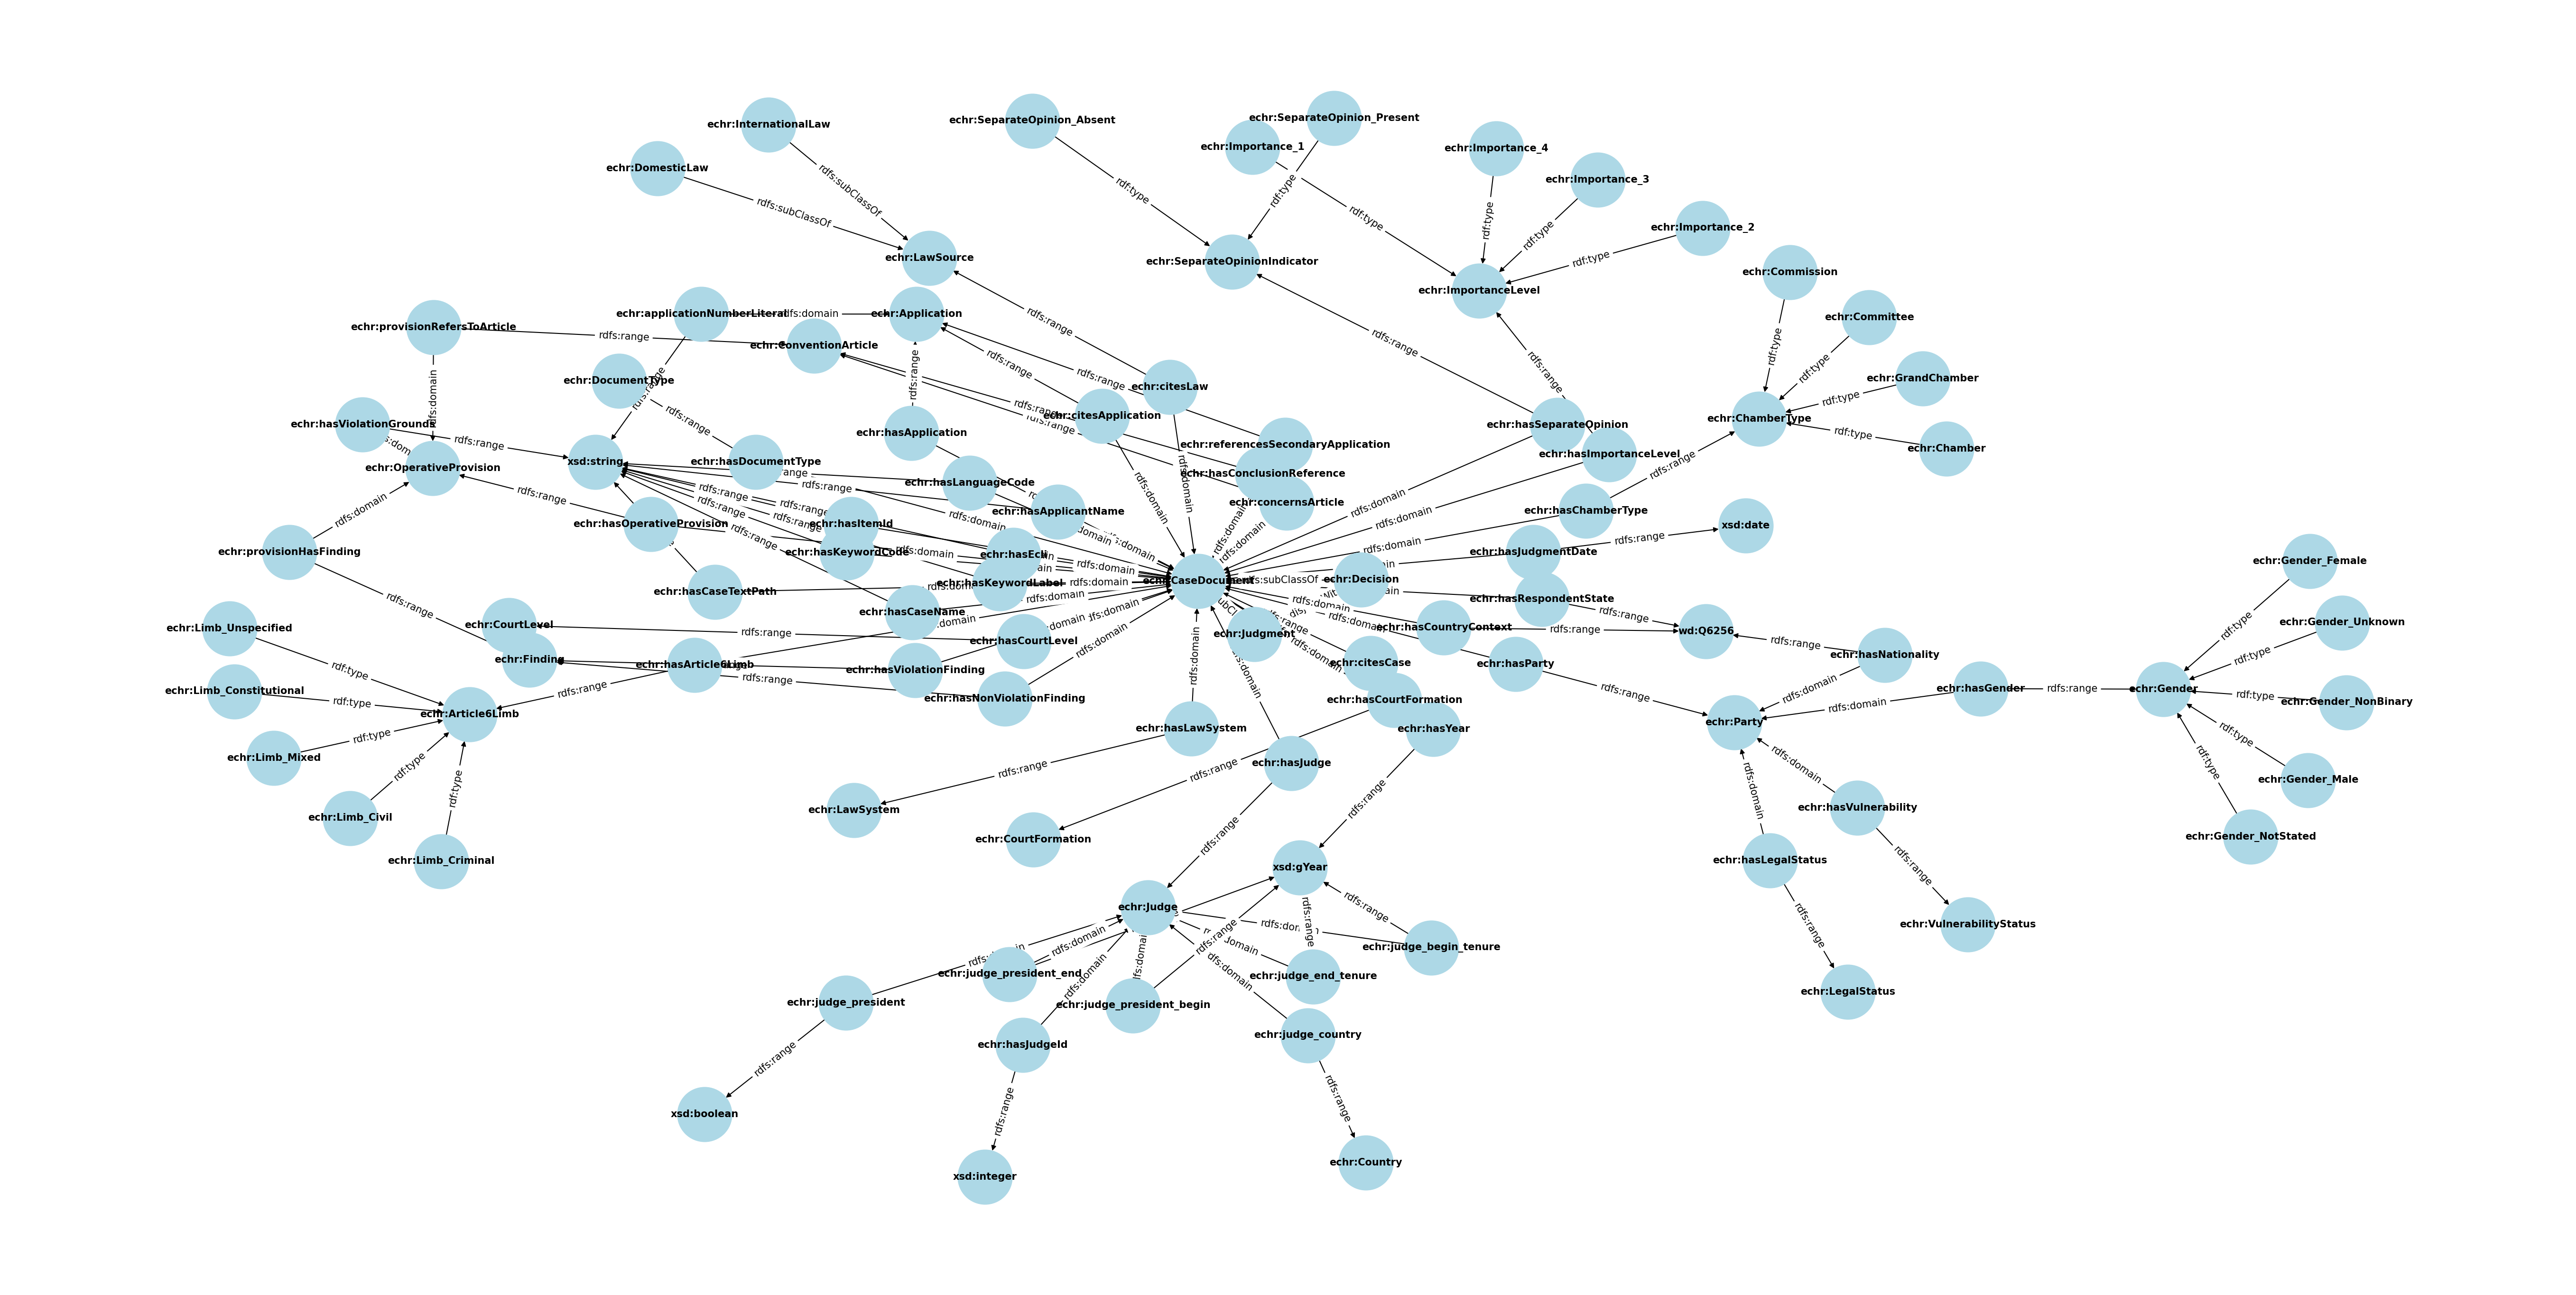

Processed seed_schema.ttl
Triples: 345


In [46]:
# TTL -> in-notebook graph workflow (seed_schema.ttl only, no file exports)
import io
import os
import shutil
from pathlib import Path
import rdflib
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import pydotplus
import pygraphviz  # Required for nx.nx_agraph.graphviz_layout
from pydotplus.graphviz import InvocationException
from rdflib.term import URIRef, Literal, BNode
from rdflib.tools.rdf2dot import rdf2dot
from IPython.display import SVG, display


def _ensure_graphviz_on_path() -> str | None:
    """Find dot.exe and ensure its bin directory is available in PATH for this kernel."""
    candidates = [
        shutil.which("dot"),
        str(Path.home() / "AppData" / "Local" / "GraphvizPortable" / "Graphviz-14.1.5-win64" / "bin" / "dot.exe"),
        str(Path.home() / "AppData" / "Local" / "Graphviz" / "bin" / "dot.exe"),
        r"C:\Program Files\Graphviz\bin\dot.exe",
    ]

    dot_path = next((p for p in candidates if p and Path(p).exists()), None)
    if dot_path is None:
        return None

    dot_bin = str(Path(dot_path).parent)
    path_parts = os.environ.get("PATH", "").split(os.pathsep)
    if dot_bin not in path_parts:
        os.environ["PATH"] = dot_bin + os.pathsep + os.environ.get("PATH", "")

    # Use Windows fonts to avoid DejaVu fallback warnings in portable installs.
    windows_fonts = r"C:\Windows\Fonts"
    if Path(windows_fonts).exists():
        os.environ.setdefault("GDFONTPATH", windows_fonts)
        os.environ.setdefault("DOTFONTPATH", windows_fonts)

    return dot_path


def visualize_inline(g):
    """Render rdf2dot graph inline in the notebook (no file writes)."""
    dot_path = _ensure_graphviz_on_path()
    if dot_path is None:
        raise InvocationException("Graphviz dot executable not found in PATH or known user locations.")

    stream = io.StringIO()
    rdf2dot(g, stream)
    dot_data = stream.getvalue()

    # Force an installed Windows font family to avoid font fallback noise.
    dot_data = dot_data.replace("digraph {", 'digraph {\n  graph [fontname="Arial"];\n  node [fontname="Arial"];\n  edge [fontname="Arial"];', 1)

    dg = pydotplus.graph_from_dot_data(dot_data)
    # SVG avoids cairo bitmap size scaling warnings for large graphs.
    svg_bytes = dg.create_svg()
    display(SVG(data=svg_bytes.decode("utf-8")))


def visualize_nx(df, scale=1, draw_edges=False):
    """Render NetworkX view inline only (no export)."""
    _ensure_graphviz_on_path()

    edges_labeled = [
        (*item[["subject", "object"]], {"relation": item["predicate"]})
        for _, item in df.iterrows()
    ]
    G = nx.DiGraph()
    G.add_edges_from(edges_labeled)

    _ = plt.figure(1, figsize=(scale * 30, scale * 15), dpi=150)

    pos = nx.nx_agraph.graphviz_layout(G, prog="neato", args="-Goverlap=false")

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color="lightblue",
        node_size=3000,
        font_size=10,
        font_weight="bold",
    )

    if draw_edges:
        edge_labels = nx.get_edge_attributes(G, "relation")
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    plt.show()


def _term_to_text(g: rdflib.Graph, term) -> str:
    """Safely format RDF terms for display without forcing literals through URI normalization."""
    if isinstance(term, URIRef):
        return g.namespace_manager.normalizeUri(term)
    if isinstance(term, Literal):
        return str(term)
    if isinstance(term, BNode):
        return f"_:{term}"
    return str(term)


def _drop_metadata_schema(g: rdflib.Graph) -> rdflib.Graph:
    """Exclude ontology header node from visualization graph to keep plots focused on domain terms."""
    metadata_schema_uri = URIRef("http://echr.coe.int/ontology#MetadataSchema")
    g_plot = rdflib.Graph()
    for prefix, namespace in g.namespace_manager.namespaces():
        g_plot.bind(prefix, namespace)

    for s, p, o in g:
        if s == metadata_schema_uri or o == metadata_schema_uri:
            continue
        g_plot.add((s, p, o))

    return g_plot


def proc(ttl_fname, plot):
    g = rdflib.Graph()
    g.parse(ttl_fname, format="turtle")

    # Remove ontology header resource from all visual representations.
    g_plot = _drop_metadata_schema(g)

    triples_onto = [[_term_to_text(g_plot, t) for t in tri] for tri in g_plot]

    df = pd.DataFrame(
        triples_onto, columns=["subject", "predicate", "object"]
    ).sort_values(["object", "subject", "predicate"])

    if plot:
        try:
            visualize_inline(g_plot)
        except InvocationException as e:
            print(f"Skipped rdf2dot inline image (Graphviz binaries not found): {e}")

        mask_trivial = df.predicate.isin(
            ["rdfs:label", "rdfs:comment"]
        ) | df.object.isin(["rdf:Property", "rdfs:Class", "owl:Ontology"])
        mask_o = df.object.apply(lambda x: x[0] == "<" and x[-1] == ">" and len(x) > 20)
        mask_s = df.subject.apply(
            lambda x: x[0] == "<" and x[-1] == ">" and len(x) > 20
        )

        df_reduced = df.loc[~mask_trivial & (~mask_o & ~mask_s)].copy()

        visualize_nx(
            df_reduced,
            scale=1.2,
            draw_edges=True,
        )

    return df


# Only visualize seed_schema.ttl
seed_schema_candidates = [Path("seed_schema.ttl"), Path("ontology/seed_schema.ttl")]
seed_schema_path = next((p for p in seed_schema_candidates if p.exists()), None)
if seed_schema_path is None:
    raise FileNotFoundError("seed_schema.ttl not found in current or ontology directory.")

ttl_fname = str(seed_schema_path)
df_ttl = proc(ttl_fname, plot=True)
print(f"Processed {ttl_fname}")
print(f"Triples: {len(df_ttl):,}")

,dataset,graph,triples
0,ontocast,urn:echr:sample:cases,13819
1,ontologies,urn:echr:ontology:seed-schema,351


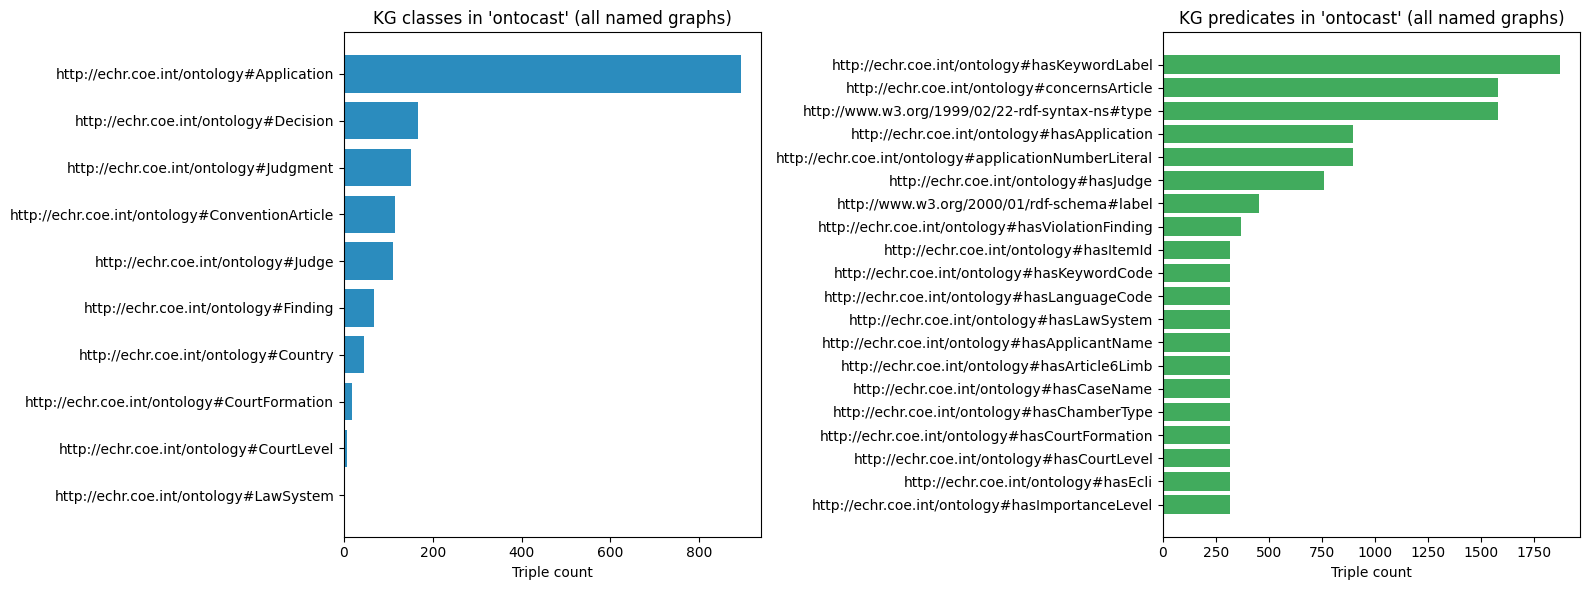

,dataset,classes,properties,total_terms
0,ontologies,25,47,72
1,ontocast,0,0,0


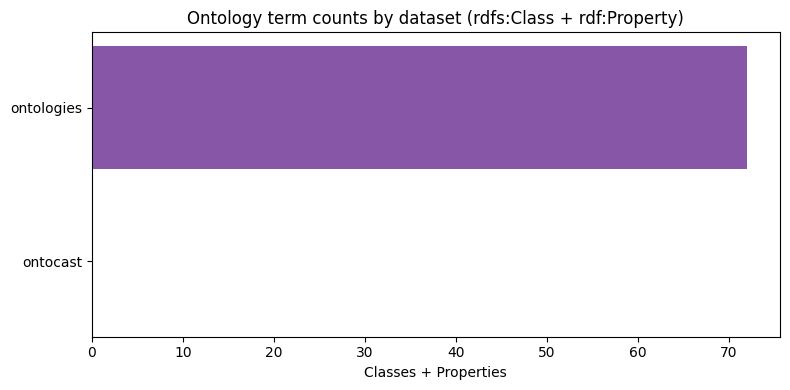

In [45]:

# Visualize Fuseki KG + ontology shape (read-only)
import json
from urllib.parse import urlencode
from urllib.request import Request, urlopen
import matplotlib.pyplot as plt
import pandas as pd

PREFIXES = """
PREFIX rdf:  <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX owl:  <http://www.w3.org/2002/07/owl#>
PREFIX echr: <http://echr.coe.int/ontology#>
""".strip()


def run_sparql_select(dataset: str, query: str) -> list[dict]:
    endpoint = f"{FUSEKI_BASE_URI}/{dataset}/query"
    payload = urlencode({"query": query}).encode("utf-8")
    req = Request(
        endpoint,
        data=payload,
        method="POST",
        headers={
            "Content-Type": "application/x-www-form-urlencoded; charset=UTF-8",
            "Accept": "application/sparql-results+json",
        },
    )
    with urlopen(req) as resp:
        data = json.loads(resp.read().decode("utf-8"))
    return data.get("results", {}).get("bindings", [])


def _binding_rows(bindings: list[dict], cols: list[str]) -> pd.DataFrame:
    rows = []
    for b in bindings:
        row = {}
        for c in cols:
            row[c] = b.get(c, {}).get("value")
        rows.append(row)
    return pd.DataFrame(rows)


def _scalar_int(bindings: list[dict], col: str, default: int = 0) -> int:
    if not bindings:
        return default
    value = bindings[0].get(col, {}).get("value")
    return int(value) if value is not None else default


# 0) Named graph diagnostic
q_graphs = """
SELECT ?g (COUNT(*) AS ?triples)
WHERE { GRAPH ?g { ?s ?p ?o } }
GROUP BY ?g
ORDER BY DESC(?triples)
"""

datasets_to_check = list(dict.fromkeys([DATASET_NAME, "ontologies", "ontocast"]))
graph_rows = []
for ds in datasets_to_check:
    try:
        b = run_sparql_select(ds, q_graphs)
        if b:
            for row in b:
                graph_rows.append({
                    "dataset": ds,
                    "graph": row.get("g", {}).get("value"),
                    "triples": int(row.get("triples", {}).get("value", 0)),
                })
        else:
            graph_rows.append({"dataset": ds, "graph": "<none>", "triples": 0})
    except Exception as e:
        graph_rows.append({"dataset": ds, "graph": f"<error: {e}>", "triples": None})

named_graphs_df = pd.DataFrame(graph_rows)
display(named_graphs_df)


# 1) KG distribution from all named graphs in main dataset
q_kg_class_dist = PREFIXES + "\n" + """
SELECT ?class (COUNT(?s) AS ?count)
WHERE {
  GRAPH ?g { ?s a ?class . }
}
GROUP BY ?class
ORDER BY DESC(?count)
LIMIT 20
"""

q_kg_pred_dist = PREFIXES + "\n" + """
SELECT ?p (COUNT(*) AS ?count)
WHERE {
  GRAPH ?g { ?s ?p ?o . }
}
GROUP BY ?p
ORDER BY DESC(?count)
LIMIT 20
"""

kg_class_df = _binding_rows(run_sparql_select(DATASET_NAME, q_kg_class_dist), ["class", "count"])
kg_pred_df = _binding_rows(run_sparql_select(DATASET_NAME, q_kg_pred_dist), ["p", "count"])

if not kg_class_df.empty:
    kg_class_df["count"] = kg_class_df["count"].astype(int)
if not kg_pred_df.empty:
    kg_pred_df["count"] = kg_pred_df["count"].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

if not kg_class_df.empty:
    cls = kg_class_df.sort_values("count", ascending=True)
    axes[0].barh(cls["class"], cls["count"], color="#2b8cbe")
    axes[0].set_title(f"KG classes in '{DATASET_NAME}' (all named graphs)")
    axes[0].set_xlabel("Triple count")
else:
    axes[0].text(0.5, 0.5, "No class data", ha="center", va="center")
    axes[0].set_title(f"KG classes in '{DATASET_NAME}'")

if not kg_pred_df.empty:
    pred = kg_pred_df.sort_values("count", ascending=True)
    axes[1].barh(pred["p"], pred["count"], color="#41ab5d")
    axes[1].set_title(f"KG predicates in '{DATASET_NAME}' (all named graphs)")
    axes[1].set_xlabel("Triple count")
else:
    axes[1].text(0.5, 0.5, "No predicate data", ha="center", va="center")
    axes[1].set_title(f"KG predicates in '{DATASET_NAME}'")

plt.tight_layout()
plt.show()


# 2) Ontology shape — schema uses rdfs:Class and rdf:Property (not OWL sub-types).
q_onto_classes    = PREFIXES + "\n" + "SELECT (COUNT(DISTINCT ?c) AS ?n) WHERE { GRAPH ?g { ?c a rdfs:Class . } }"
q_onto_properties = PREFIXES + "\n" + "SELECT (COUNT(DISTINCT ?p) AS ?n) WHERE { GRAPH ?g { ?p a rdf:Property . } }"

candidate_datasets = list(dict.fromkeys(["ontologies", "ontocast", DATASET_NAME]))
onto_rows = []

for ds in candidate_datasets:
    try:
        c = _scalar_int(run_sparql_select(ds, q_onto_classes), "n", 0)
        p = _scalar_int(run_sparql_select(ds, q_onto_properties), "n", 0)
        onto_rows.append({
            "dataset": ds,
            "classes": c,
            "properties": p,
            "total_terms": c + p,
        })
    except Exception as e:
        onto_rows.append({
            "dataset": ds,
            "classes": None,
            "properties": None,
            "total_terms": None,
            "error": str(e),
        })

ontology_summary = pd.DataFrame(onto_rows)
display(ontology_summary)

plot_df = ontology_summary.dropna(subset=["total_terms"]).copy()
if not plot_df.empty and plot_df["total_terms"].sum() > 0:
    plot_df = plot_df.sort_values("total_terms", ascending=True)
    plt.figure(figsize=(8, 4))
    plt.barh(plot_df["dataset"], plot_df["total_terms"], color="#8856a7")
    plt.title("Ontology term counts by dataset (rdfs:Class + rdf:Property)")
    plt.xlabel("Classes + Properties")
    plt.tight_layout()
    plt.show()
else:
    print("No ontology declarations found in inspected datasets.")


### Text-Based Onto improvement and extraction using ontocast

- put into a seperate script ontocast_run.py due to compatibility issues with .ipynb files

In [ ]:
# Export sampled_metadata (including full_text) for use in run_ontocast.py
# Parquet preserves polars types (including list columns) without pickle fragility.
from pathlib import Path

export_path = Path("../data/sampled_metadata_with_text.parquet")
sampled_metadata.write_parquet(export_path)

print(f"Exported {sampled_metadata.height} rows to {export_path.resolve()}")
print(f"Columns: {sampled_metadata.columns}")
print(f"English cases with full_text: ",
    sampled_metadata.filter(
        pl.col('full_text').is_not_null()
        & (pl.col('full_text').cast(pl.Utf8).str.len_chars() > 0)
    ).height
)

Exported 317 rows to C:\Postdoc\Article_6\data\sampled_metadata_with_text.parquet
Columns: ['conclusion', 'violation', 'languageisocode', 'originatingbody', 'itemid', 'secondary_appno', 'importance', 'judgementdate', 'case_name', 'ecli', 'judges', 'nonviolation', 'judgment_type', 'separateopinion', 'respondent', 'cited_appno', 'kpthesaurus', 'court_level', 'article', 'case_appno', 'case_text_path', 'appellant', 'country_name', 'judges_id', 'judge_similarity_pct', 'kpthesaurus_labels', 'article_6_limb', 'law_system', 'source', 'year', 'full_text', 'introduction', 'procedure', 'facts', 'legal_framework', 'law', 'reasons', 'appendix']
English cases with full_text:  317


: 

#### NOT USING RN 

Prompt pipeline prepared (no extraction/upload run).
{'sample_cases': 317, 'judges_metadata_rows': 229, 'policy_source': 'C:\\Postdoc\\Article_6\\ontology\\ONTOCAST_AGENT_POLICY.md', 'how_to_use': 'Call prepare_batch_prompt_payload(sampled_metadata, judges_metadata_case, limit=...) when ready.'}


In [ ]:
from pathlib import Path
import pandas as pd

# No API calls: estimate cost from local corpus size + explicit assumptions.
judgment_dir = DATA_DIR / "judgment_text"
decision_dir = DATA_DIR / "decision_text"

judgment_files = list(judgment_dir.glob("*.html"))
decision_files = list(decision_dir.glob("*.html"))

j_count = len(judgment_files)
d_count = len(decision_files)
total_cases = j_count + d_count

j_bytes = sum(p.stat().st_size for p in judgment_files)
d_bytes = sum(p.stat().st_size for p in decision_files)
total_bytes = j_bytes + d_bytes

# Approximation: 1 token ~= 4 characters/bytes for mixed legal text.
base_input_tokens = total_bytes / 4.0

# Model pricing (USD per 1M tokens) - adjust if your account pricing differs.
model_prices = {
    "gpt-4o-mini": {"input_per_1m": 0.15, "output_per_1m": 0.60},
    "gpt-4o": {"input_per_1m": 5.00, "output_per_1m": 15.00},
    "gpt-4.1-mini": {"input_per_1m": 0.40, "output_per_1m": 1.60},
}

# OntoCast usage scenarios (no API, heuristic multipliers):
# input_multiplier: repeated prompting overhead from chunking + renderer/critic loops
# output_ratio: output tokens generated per input token
scenarios = {
    "low": {"input_multiplier": 2.5, "output_ratio": 0.15},
    "medium": {"input_multiplier": 4.0, "output_ratio": 0.25},
    "high": {"input_multiplier": 6.0, "output_ratio": 0.35},
}

# Local OntoCast cache sensitivity:
# 0.0 means first run (no cache reuse), higher values simulate reruns.
cache_hit_rates = {
    "first_run_0pct": 0.00,
    "rerun_50pct": 0.50,
    "rerun_80pct": 0.80,
    "rerun_95pct": 0.95,
}

rows = []
for scenario_name, s in scenarios.items():
    uncached_input_tokens = base_input_tokens * s["input_multiplier"]
    uncached_output_tokens = uncached_input_tokens * s["output_ratio"]

    for cache_label, hit_rate in cache_hit_rates.items():
        # Assume cache hits return stored completions and avoid billed API tokens.
        billed_input_tokens = uncached_input_tokens * (1.0 - hit_rate)
        billed_output_tokens = uncached_output_tokens * (1.0 - hit_rate)

        for model, price in model_prices.items():
            input_cost = (billed_input_tokens / 1_000_000.0) * price["input_per_1m"]
            output_cost = (billed_output_tokens / 1_000_000.0) * price["output_per_1m"]
            total_cost = input_cost + output_cost

            rows.append({
                "scenario": scenario_name,
                "cache_profile": cache_label,
                "cache_hit_rate": hit_rate,
                "model": model,
                "cases": total_cases,
                "uncached_input_tokens_est": round(uncached_input_tokens),
                "uncached_output_tokens_est": round(uncached_output_tokens),
                "billed_input_tokens_est": round(billed_input_tokens),
                "billed_output_tokens_est": round(billed_output_tokens),
                "input_cost_usd": round(input_cost, 2),
                "output_cost_usd": round(output_cost, 2),
                "total_cost_usd": round(total_cost, 2),
                "cost_per_case_usd": round(total_cost / total_cases, 4),
            })

cost_df = pd.DataFrame(rows).sort_values(["model", "scenario", "cache_hit_rate"])

summary = pd.DataFrame([
    {
        "judgment_cases": j_count,
        "decision_cases": d_count,
        "total_cases": total_cases,
        "judgment_bytes": j_bytes,
        "decision_bytes": d_bytes,
        "total_bytes": total_bytes,
        "base_input_tokens_est": round(base_input_tokens),
    }
])

print("Corpus summary:")
display(summary)

print("Estimated OntoCast run cost (no API calls; scenario + cache profile):")
display(cost_df)

### Article 6 Country Maps (Normalized Shares)

This section creates:

1. A static world map for the full period showing each country's share of all Article 6 cases (%).
2. A GIF where each frame is a 6-year window, showing how country shares change over time.

Outputs are written to `../results/quarto/figures/`.

In [9]:
from pathlib import Path
import re

import polars as pl
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import pycountry

# Paths
DATA_DIR = Path("../data")
OUT_DIR = Path("../results/quarto/figures")
OUT_DIR.mkdir(parents=True, exist_ok=True)

judgments_path = DATA_DIR / "art_6_judgments_metadata_processed.json"
decisions_path = DATA_DIR / "art_6_decisions_metadata_processed.json"

# Load processed metadata
judgments_df = pl.read_ndjson(judgments_path, infer_schema_length=None).with_columns(
    pl.lit("judgments").alias("source")
)
decisions_df = pl.read_ndjson(decisions_path, infer_schema_length=None).with_columns(
    pl.lit("decisions").alias("source")
)
all_cases = pl.concat([judgments_df, decisions_df], how="diagonal_relaxed")

# Derive year robustly
all_cases = all_cases.with_columns(
    pl.coalesce(
        [
            pl.col("judgementdate").cast(pl.Utf8, strict=False).str.slice(0, 4).cast(pl.Int32, strict=False),
            pl.col("ecli").cast(pl.Utf8, strict=False).str.extract(r":(\d{4}):", 1).cast(pl.Int32, strict=False),
        ]
    ).alias("year")
)


def first_country_name(value):
    if value is None:
        return None
    if isinstance(value, list) and len(value) > 0:
        for item in value:
            if item is not None and str(item).strip() != "":
                return str(item).strip()
        return None
    if isinstance(value, str) and value.strip() != "":
        return value.strip()
    return None


country_aliases = {
    "turkey": "TUR",
    "republic of turkey": "TUR",
    "turkiye": "TUR",
    "turkiye republic": "TUR",
    "türkiye": "TUR",
    "türkiye cumhuriyeti": "TUR",
    "russia": "RUS",
    "russian federation": "RUS",
    "moldova": "MDA",
    "czech republic": "CZE",
    "north macedonia": "MKD",
    "bosnia and herzegovina": "BIH",
    "united kingdom": "GBR",
}


def extract_respondent_alpha3(value):
    if value is None:
        return None
    if isinstance(value, list):
        for item in value:
            text = str(item).strip().upper()
            if re.fullmatch(r"[A-Z]{3}", text):
                return text
        return None

    text = str(value).strip()
    # Handles serialized lists such as "['TUR']" as well as plain values.
    hits = re.findall(r"[A-Z]{3}", text.upper())
    return hits[0] if hits else None


def to_iso3(country_name, respondent_code):
    # Prefer explicit country name if available.
    if country_name:
        key = country_name.strip().lower()
        if key in country_aliases:
            return country_aliases[key]
        try:
            match = pycountry.countries.lookup(country_name)
            if hasattr(match, "alpha_3"):
                return match.alpha_3
        except LookupError:
            pass

    # Fall back to respondent code in metadata (typically alpha-3 in this corpus).
    if respondent_code:
        code = respondent_code.strip().upper()
        if len(code) == 3:
            return code
        try:
            match = pycountry.countries.lookup(code)
            if hasattr(match, "alpha_3"):
                return match.alpha_3
        except LookupError:
            pass

    return None


# Convert to pandas for flexible row-wise normalization logic
pdf = all_cases.select(["itemid", "source", "year", "country_name", "respondent"]).to_pandas()
pdf["country_name_first"] = pdf["country_name"].apply(first_country_name)
pdf["respondent_code"] = pdf["respondent"].apply(extract_respondent_alpha3)
pdf["iso3"] = [
    to_iso3(country_name=cn, respondent_code=rc)
    for cn, rc in zip(pdf["country_name_first"], pdf["respondent_code"])
]

# Keep only rows that can be mapped to countries
map_df = pdf[pdf["iso3"].notna()].copy()

print(f"Loaded cases: {len(pdf):,}")
print(f"Mappable cases (country -> ISO3): {len(map_df):,}")
print(f"Countries represented: {map_df['iso3'].nunique():,}")

# Europe scope list, aligned with GIF section.
EUROPE_ISO3 = {
    "ALB", "AND", "ARM", "AUT", "AZE", "BEL", "BIH", "BGR", "HRV", "CYP", "CZE",
    "DNK", "EST", "FIN", "FRA", "GEO", "DEU", "GRC", "HUN", "ISL", "IRL", "ITA",
    "LVA", "LIE", "LTU", "LUX", "MLT", "MDA", "MCO", "MNE", "NLD", "MKD", "NOR",
    "POL", "PRT", "ROU", "RUS", "SMR", "SRB", "SVK", "SVN", "ESP", "SWE", "CHE",
    "TUR", "UKR", "GBR"
}

# Static normalized country share over full period (Europe only)
static_df = map_df[map_df["iso3"].isin(EUROPE_ISO3)].copy()

static_counts = (
    static_df.groupby("iso3", dropna=False)
    .size()
    .reset_index(name="case_count")
)

# Keep all Europe countries in output, including TUR even when share is 0 in a subset.
static_counts = (
    static_counts.set_index("iso3")
    .reindex(sorted(EUROPE_ISO3), fill_value=0)
    .rename_axis("iso3")
    .reset_index()
)

static_total = static_counts["case_count"].sum()
static_counts["pct_share"] = (static_counts["case_count"] / static_total) * 100.0

fixed_geo = dict(
    scope="world",
    projection=dict(type="mercator"),
    center=dict(lat=54, lon=15),
    lataxis=dict(range=[30, 73]),
    lonaxis=dict(range=[-25, 55]),
)

fig_static = px.choropleth(
    static_counts,
    locations="iso3",
    color="pct_share",
    color_continuous_scale="YlOrRd",
    range_color=(0, float(static_counts["pct_share"].max())),
    title="Article 6 Cases by Country (% of all Europe cases, full period)",
    labels={"pct_share": "% share"},
    scope="world",
)
fig_static.update_layout(margin=dict(l=0, r=0, t=60, b=0), geo=fixed_geo)

turkey_row = static_counts.loc[static_counts["iso3"] == "TUR"].iloc[0]
fig_static.add_trace(go.Scattergeo(
    lon=[35.0],
    lat=[39.0],
    mode="markers+text",
    marker=dict(size=6, color="black"),
    text=[f"Turkey ({int(turkey_row['case_count']):,})"],
    textposition="top right",
    showlegend=False,
))

static_html = OUT_DIR / "art6_country_share_full_period_europe.html"
static_png = OUT_DIR / "art6_country_share_full_period_europe.png"

fig_static.write_html(static_html)
fig_static.write_image(static_png, scale=2, width=1400, height=900)

fig_static.show()

turkey_static_cases = int(static_counts.loc[static_counts["iso3"] == "TUR", "case_count"].sum())
if turkey_static_cases <= 0:
    raise ValueError("Turkey is missing from static map input data.")
print(f"Turkey (TUR) mapped cases in static data: {turkey_static_cases}")
print(f"Saved static Europe map HTML: {static_html.resolve()}")
print(f"Saved static Europe map PNG:  {static_png.resolve()}")

Loaded cases: 48,919
Mappable cases (country -> ISO3): 48,919
Countries represented: 49


Turkey (TUR) mapped cases in static data: 5648
Saved static Europe map HTML: C:\Postdoc\Article_6\results\quarto\figures\art6_country_share_full_period_europe.html
Saved static Europe map PNG:  C:\Postdoc\Article_6\results\quarto\figures\art6_country_share_full_period_europe.png


In [ ]:
from PIL import Image, ImageSequence

# Temporal bins (normalized within each bin), Europe-focused
# Includes Council of Europe states and common transcontinental members in ECHR context.
EUROPE_ISO3 = {
    "ALB", "AND", "ARM", "AUT", "AZE", "BEL", "BIH", "BGR", "HRV", "CYP", "CZE",
    "DNK", "EST", "FIN", "FRA", "GEO", "DEU", "GRC", "HUN", "ISL", "IRL", "ITA",
    "LVA", "LIE", "LTU", "LUX", "MLT", "MDA", "MCO", "MNE", "NLD", "MKD", "NOR",
    "POL", "PRT", "ROU", "RUS", "SMR", "SRB", "SVK", "SVN", "ESP", "SWE", "CHE",
    "TUR", "UKR", "GBR"
}

temporal_df = map_df[
    map_df["year"].notna()
    & map_df["iso3"].isin(EUROPE_ISO3)
    & (map_df["year"].astype(int) <= 2025)
].copy()
temporal_df["year"] = temporal_df["year"].astype(int)

if temporal_df.empty:
    raise ValueError("No Europe-mapped cases with valid year available for temporal map generation.")

min_year = int(temporal_df["year"].min())
max_year = int(temporal_df["year"].max())

# Explicitly track Turkey presence in filtered data.
turkey_cases = int((temporal_df["iso3"] == "TUR").sum())

# Period structure: 1959-1964, then 5-year bins, with final capped bin 2020-2025.
def assign_period_bounds(y: int) -> tuple[int, int]:
    if y <= 1964:
        return 1959, 1964
    if y >= 2020:
        return 2020, 2025
    start = 1965 + ((y - 1965) // 5) * 5
    end = start + 4
    return start, end

period_bounds = temporal_df["year"].apply(assign_period_bounds)
temporal_df["bin_start"] = period_bounds.apply(lambda t: t[0])
temporal_df["bin_end"] = period_bounds.apply(lambda t: t[1])
temporal_df["period"] = temporal_df["bin_start"].astype(str) + "-" + temporal_df["bin_end"].astype(str)

bin_country_counts = (
    temporal_df.groupby(["period", "bin_start", "iso3"], dropna=False)
    .size()
    .reset_index(name="case_count")
)

bin_totals = (
    temporal_df.groupby(["period", "bin_start"], dropna=False)
    .size()
    .reset_index(name="period_total")
)

periods_df = (
    bin_totals[["period", "bin_start"]]
    .drop_duplicates()
    .sort_values("bin_start")
)
countries_df = pd.DataFrame({"iso3": sorted(EUROPE_ISO3)})
all_period_country = (
    periods_df.assign(_k=1)
    .merge(countries_df.assign(_k=1), on="_k", how="inner")
    .drop(columns=["_k"])
)

anim_df = all_period_country.merge(
    bin_country_counts,
    on=["period", "bin_start", "iso3"],
    how="left",
)
anim_df["case_count"] = anim_df["case_count"].fillna(0).astype(int)
anim_df = anim_df.merge(bin_totals, on=["period", "bin_start"], how="left")
anim_df["pct_share"] = (anim_df["case_count"] / anim_df["period_total"]) * 100.0
anim_df = anim_df.sort_values(["bin_start", "iso3"]).reset_index(drop=True)

# Save one frame per period, then stitch into GIF.
frames_dir = OUT_DIR / "art6_country_share_6y_frames"
frames_dir.mkdir(parents=True, exist_ok=True)

period_order = (
    anim_df[["period", "bin_start"]]
    .drop_duplicates()
    .sort_values("bin_start")["period"]
    .tolist()
)

max_pct = float(anim_df["pct_share"].max())
frame_paths = []

# Fixed Europe viewport so frame geometry stays identical.
fixed_geo = dict(
    scope="world",
    projection=dict(type="mercator"),
    center=dict(lat=54, lon=15),
    lataxis=dict(range=[30, 73]),
    lonaxis=dict(range=[-25, 55]),
)

for period in period_order:
    frame_df = anim_df[anim_df["period"] == period]

    fig = px.choropleth(
        frame_df,
        locations="iso3",
        color="pct_share",
        color_continuous_scale="YlOrRd",
        range_color=(0, max_pct),
        title="Article 6 Cases by Country (% share), Europe",
        labels={"pct_share": "% share"},
        scope="world",
    )
    fig.update_layout(margin=dict(l=0, r=0, t=60, b=0), geo=fixed_geo)
    fig.add_annotation(
        x=0.99,
        y=0.99,
        xref="paper",
        yref="paper",
        text=f"Period: {period}",
        showarrow=False,
        xanchor="right",
        yanchor="top",
        font=dict(size=20, color="black"),
        bgcolor="rgba(255,255,255,0.85)",
        bordercolor="rgba(0,0,0,0.35)",
        borderwidth=1,
    )

    frame_path = frames_dir / f"art6_country_share_{period}.png"
    fig.write_image(frame_path, scale=2, width=1400, height=900)
    frame_paths.append(frame_path)

# Build GIF with robust timing across viewers.
# Some players clamp long per-frame delays, so we repeat each period as 3x 1-second subframes.
gif_path = OUT_DIR / "art6_country_share_6year.gif"
repeat_each_period = 3
subframe_duration_ms = 1000
expanded_frames = []
for path in frame_paths:
    with Image.open(path) as im:
        base = im.convert("P", palette=Image.ADAPTIVE)
        for _ in range(repeat_each_period):
            expanded_frames.append(base.copy())

expanded_frames[0].save(
    gif_path,
    save_all=True,
    append_images=expanded_frames[1:],
    duration=subframe_duration_ms,
    loop=0,
    optimize=False,
    disposal=2,
)

# Verify encoded timing from file metadata.
with Image.open(gif_path) as gif_check:
    encoded_durations = [fr.info.get("duration", 0) for fr in ImageSequence.Iterator(gif_check)]
encoded_total_seconds = sum(encoded_durations) / 1000.0

# Also provide an interactive animated HTML version (Europe-focused).
fig_anim = px.choropleth(
    anim_df,
    locations="iso3",
    color="pct_share",
    animation_frame="period",
    color_continuous_scale="YlOrRd",
    range_color=(0, max_pct),
    title="Article 6 Cases by Country (% share), Europe, 6-year windows",
    labels={"pct_share": "% share", "period": "Period"},
    category_orders={"period": period_order},
    scope="world",
)
fig_anim.update_layout(margin=dict(l=0, r=0, t=60, b=0), geo=fixed_geo)
for fr in fig_anim.frames:
    fr.layout.update(annotations=[dict(
        x=0.99,
        y=0.99,
        xref="paper",
        yref="paper",
        text=f"Period: {fr.name}",
        showarrow=False,
        xanchor="right",
        yanchor="top",
        font=dict(size=20, color="black"),
        bgcolor="rgba(255,255,255,0.85)",
        bordercolor="rgba(0,0,0,0.35)",
        borderwidth=1,
    )])

# Match interactive playback speed to GIF (3s per frame).
if fig_anim.layout.updatemenus and len(fig_anim.layout.updatemenus) > 0:
    fig_anim.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 3000
    fig_anim.layout.updatemenus[0].buttons[0].args[1]["transition"]["duration"] = 0
if fig_anim.layout.sliders and len(fig_anim.layout.sliders) > 0:
    for step in fig_anim.layout.sliders[0].steps:
        step.args[1]["frame"]["duration"] = 3000
        step.args[1]["transition"]["duration"] = 0

anim_html = OUT_DIR / "art6_country_share_6year_animated.html"
fig_anim.write_html(anim_html)

print(f"Year span in Europe filter: {min_year} to {max_year}")
print(f"Turkey (TUR) cases in Europe filter: {turkey_cases}")
print("Turkey per period (first 5):")
print(anim_df[anim_df["iso3"] == "TUR"][["period", "case_count"]].head())
print(f"Saved GIF (effective 3s/frame):  {gif_path.resolve()}")
print(f"GIF frame count: {len(encoded_durations)} (base periods: {len(period_order)}, repeats per period: {repeat_each_period})")
print(f"Encoded duration summary (ms): unique={sorted(set(encoded_durations))}")
print(f"Encoded total duration (s): {encoded_total_seconds:.1f}")
print(f"Saved animated HTML map: {anim_html.resolve()}")
print(f"Saved {len(frame_paths)} frame PNGs in: {frames_dir.resolve()}")